<a href="https://colab.research.google.com/github/worawatpr-gh/SC663402-Data-Warehouse-and-Big-Data-Analytics-2026-1/blob/main/SC663402_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

#วรวัฒน์  พรหมคุณ 673020262-1 sec.1

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!


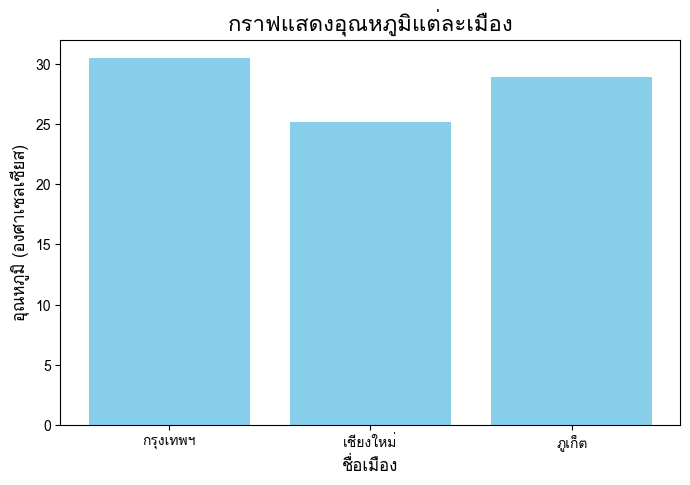

In [ ]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [ ]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


คำสั่ง s["a"] และ s.iloc[0] ได้ค่าเหมือนกันคือ 10 แต่เลือกข้อมูลคนละวิธี โดย s["a"] เลือกจากชื่อ Index คือ "a" ส่วน s.iloc[0] เลือกจากตำแหน่งของข้อมูล โดย 0 หมายถึงข้อมูลตัวแรก ดังนั้นถ้าเรารู้ชื่อ Index และต้องการข้อมูลตัวนั้นโดยตรง ควรใช้ s["a"] แต่ถ้าต้องการเลือกข้อมูลตามตำแหน่ง เช่น ตัวแรก ตัวที่สอง หรือตัวที่ห้า ควรใช้ .iloc ส่วน s[["a", "c"]] ใช้สำหรับเลือกหลายข้อมูลพร้อมกัน จึงได้ผลลัพธ์เป็น Series ที่มี 2 ค่า คือ 10 และ 30

##ในทางปฏิบัติ
หากกำลังทำงานกับ DataFrame แล้วรู้ว่าต้องการข้อมูลจากชื่อหรือ Label ใด ให้เลือกด้วยชื่อจะอ่านโค้ดง่ายกว่า แต่ถ้าต้องการเลือกตามตำแหน่งจริง ๆ ให้ใช้ .iloc

In [ ]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


คำสั่งทั้งสองใช้เลือกคอลัมน์ city เหมือนกัน แต่ได้ผลลัพธ์คนละชนิด

df["city"] ได้ผลลัพธ์เป็น Series ซึ่งเป็นข้อมูล 1 มิติ และมีรูปร่าง (จำนวนแถว,)

ส่วน df[["city"]] ได้ผลลัพธ์เป็น DataFrame ซึ่งเป็นข้อมูล 2 มิติ และมีรูปร่าง (จำนวนแถว, 1)

พูดง่าย ๆ คือ

df["city"] หมายถึง "เอาข้อมูลในคอลัมน์ city ออกมา"

ส่วน

df[["city"]] หมายถึง "เอา DataFrame ที่มีคอลัมน์ city อยู่ 1 คอลัมน์"

##ในทางปฏิบัติ
ถ้าจะนำคอลัมน์ city ไปใช้งานหรือคำนวณทั่วไป สามารถใช้ df["city"] ได้ แต่ถ้าต้องการรักษารูปแบบ DataFrame หรือต้องการเลือกหลายคอลัมน์พร้อมกัน เช่น city, country และ region ควรใช้ df[["city", "country", "region"]]

In [ ]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


สองคำสั่งนี้ใช้สำหรับเลือกแถวเหมือนกัน แต่มีวิธีนับช่วงต่างกัน

df.loc[0:3] จะเลือกแถวที่มี Index ตั้งแต่ 0 ถึง 3 รวมแถวที่ 3 ด้วย ดังนั้นจะได้ 4 แถว

ส่วน df.iloc[0:3] จะเลือกตามตำแหน่ง 0, 1 และ 2 โดย ไม่รวมตำแหน่งที่ 3 จึงได้ 3 แถว

ดังนั้นถ้า DataFrame มี 10 คอลัมน์ ผลลัพธ์จะประมาณนี้

df.loc[0:3].shape → (4, 10)
df.iloc[0:3].shape → (3, 10)

##ในทางปฏิบัติ
ให้จำง่าย ๆ ว่า .loc เหมาะกับการเลือกข้อมูลโดยอ้างอิงจาก Label หรือเงื่อนไข เช่น ต้องการข้อมูลของเมืองหนึ่ง หรือแถวที่มีเงื่อนไขบางอย่าง ส่วน .iloc เหมาะกับการเลือกตามตำแหน่ง เช่น ต้องการ 10 แถวแรก หรือเลือกคอลัมน์ที่อยู่ตำแหน่งที่กำหนด

In [ ]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


ทั้งสองคำสั่งใช้ดูจำนวนข้อมูลในแต่ละเมือง แต่มีความหมายต่างกัน

df.groupby("city")["temperature_c"].count() จะนับเฉพาะค่าของ temperature_c ที่มีข้อมูลอยู่ ถ้าอุณหภูมิเป็นค่าว่าง จะไม่นับค่านั้น

ส่วน df.groupby("city").size() จะนับจำนวนแถวทั้งหมดของแต่ละเมือง ไม่ว่าจะมีค่า temperature_c หรือไม่ก็ตาม

ตัวอย่างเช่น สมมติว่า Tokyo มีข้อมูล 100 แถว แต่มีอุณหภูมิหายไป 5 แถว

.count() จะได้ 95
.size() จะได้ 100

##ในทางปฏิบัติ
ถ้าต้องการรู้ว่า แต่ละเมืองมีข้อมูลทั้งหมดกี่แถว ให้ใช้ .size()

แต่ถ้าต้องการตรวจสอบว่า แต่ละเมืองมีข้อมูลอุณหภูมิที่ใช้งานได้กี่ค่า ให้ใช้ .count()

คำสั่งนี้จึงมีประโยชน์มากเวลาเราตรวจสอบ Missing Values ใน Dataset

In [ ]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


คำสั่งทั้งสองคำนวณค่าเฉลี่ยของ temperature_c เหมือนกัน และค่าที่คำนวณได้ก็เหมือนกัน แต่รูปแบบผลลัพธ์ต่างกัน

df.groupby("city")["temperature_c"].mean()

จะได้ผลลัพธ์เป็น Series

ส่วน

df.groupby("city")[["temperature_c"]].mean()

จะได้ผลลัพธ์เป็น DataFrame

##ในทางปฏิบัติ
ถ้าต้องการเอาค่าเฉลี่ยของ temperature_c ไปคำนวณต่อแบบข้อมูล 1 คอลัมน์ ใช้แบบแรกได้ง่ายกว่า

แต่ถ้าต้องการเก็บผลลัพธ์ไว้เป็น DataFrame หรือในอนาคตต้องการคำนวณหลายคอลัมน์พร้อมกัน เช่น อุณหภูมิ ความชื้น และความเร็วลม ก็ควรใช้แบบที่สอง เช่น

df.groupby("city")[["temperature_c", "humidity_pct", "wind_speed_kmh"]].mean()

วิธีนี้จะเหมาะกับการทำตารางสรุปข้อมูลมากกว่า

In [ ]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


ข้อมูล a คือ

x = 1, y = 2, z = 3

ส่วน b คือ

z = 10, y = 20, x = 30

แม้ข้อมูลจะเรียงลำดับไม่เหมือนกัน แต่เมื่อใช้

a + b

Pandas จะดูที่ Index แล้วจับคู่ข้อมูลที่มีชื่อเหมือนกัน

จึงได้

x    31
y    22
z    13

เพราะ

x → 1 + 30 = 31,
y → 2 + 20 = 22,
z → 3 + 10 = 13

แต่ถ้าใช้

a.to_numpy() + b.to_numpy()

ข้อมูลจะถูกเปลี่ยนเป็น NumPy array และไม่สนใจ Index แล้ว จึงคำนวณตามตำแหน่ง

[1, 2, 3] + [10, 20, 30]

ได้

[11, 22, 33]

##ในทางปฏิบัติ
ถ้าข้อมูลของเรามี Index ที่มีความหมาย และต้องการให้ข้อมูลที่มี Index เดียวกันถูกนำมาคำนวณคู่กัน ควรใช้การคำนวณของ Pandas เช่น a + b

แต่ถ้าต้องการคำนวณตัวเลขตามตำแหน่งโดยไม่สนใจ Index สามารถใช้ .to_numpy() ได้

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [ ]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [ ]:
# คำตอบข้อ 2.1
#สร้าง rain_by_city โดยใช้ groupby() เพื่อรวมปริมาณฝนของแต่ละเมืองด้วย sum()
rain_by_city = df.groupby("city", observed=True)["rainfall_mm"].sum()

#1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
top3_rainy_cities = rain_by_city.nlargest(3)

#2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด
rain_percentage = (rain_by_city / rain_by_city.sum() * 100).round(2)

#3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง
average_rain = rain_by_city.mean()
count_above_average = (rain_by_city > average_rain).sum()

print("1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรกคือ:")
print(top3_rainy_cities)

print("\n2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมดคือ:")
print(rain_percentage)

print(f"\n3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมืองมีทั้งหมด {count_above_average} เมือง")

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรกคือ:
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมดคือ:
city
Auckland         4.22
Bangkok          8.21
Beijing          3.00
Berlin           3.21
Buenos Aires     3.65
Cairo            1.47
Cape Town        2.87
Chiang Mai       5.22
Lagos            7.82
Lima             2.16
London           3.27
Los Angeles      2.03
Mexico City      3.66
Moscow           2.96
Mumbai           5.84
Nairobi          4.74
New York         3.78
Paris            3.99
Sao Paulo        5.07
Singapore       10.43
Sydney           3.97
Tokyo            4.61
Toronto          3.81
Name: rainfall_mm, dtype: float64

3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมืองมีทั้งหมด 8 เมือง


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [ ]:
# คำตอบข้อ 2.2
city_profile = (
    df.groupby("city")
      .agg(
          country=("country", "first"),
          region=("region", "first"),
          n_records=("record_id", "count"),
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum")
      )
      .reset_index()
)

print(city_profile)

            city       country         region  n_records   avg_temp  \
0       Auckland   New Zealand        Oceania         90  17.804444   
1        Bangkok      Thailand           Asia         91  32.453846   
2        Beijing         China           Asia         90  15.598876   
3         Berlin       Germany         Europe         90  12.383146   
4   Buenos Aires     Argentina  South America         90  19.171910   
5          Cairo         Egypt         Africa         91  26.089888   
6      Cape Town  South Africa         Africa         90  30.162921   
7     Chiang Mai      Thailand           Asia         91  29.680220   
8          Lagos       Nigeria         Africa         90  29.494253   
9           Lima          Peru  South America         90  21.490000   
10        London            UK         Europe         90  13.490909   
11   Los Angeles           USA  North America         90  20.657303   
12   Mexico City        Mexico  North America         90  19.187778   
13    

---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [ ]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [ ]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [ ]:
# คำตอบข้อ 3.1
df31 = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date",
        "city",
        "region",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm"
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={
        "city": "category",
        "region": "category"
    },
    index_col="city"
)
print(df31.dtypes)
df31.info()

date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [ ]:
# คำตอบข้อ 3.2
# ตารางที่นำเข้าตามปกติ
df_normal = pd.read_csv(BASE + "world_weather_sample.csv")

# ตารางจากโจทย์ 3.1
df_optimized = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date",
        "city",
        "region",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm"
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={
        "city": "category",
        "region": "category"
    },
    index_col="city"
)

# คำนวณหน่วยความจำรวม
memory_normal = df_normal.memory_usage(deep=True).sum()
memory_optimized = df_optimized.memory_usage(deep=True).sum()

# คำนวณเปอร์เซ็นต์ที่ลดลง
reduction_percent = (
    (memory_normal - memory_optimized)
    / memory_normal
    * 100
)

print(f"หน่วยความจำตารางปกติคือ: {memory_normal} bytes")
print(f"หน่วยความจำตารางจากข้อ 3.1 คือ: {memory_optimized} bytes")
print(f"หน่วยความจำลดลง: {round(reduction_percent, 2)} %")

print("\nหน่วยความจำของแต่ละคอลัมน์ - ตารางปกติ")
print(df_normal.memory_usage(deep=True))

print("\nหน่วยความจำของแต่ละคอลัมน์ - ตารางจากข้อ 3.1")
print(df_optimized.memory_usage(deep=True))

หน่วยความจำตารางปกติคือ: 571645 bytes
หน่วยความจำตารางจากข้อ 3.1 คือ: 72917 bytes
หน่วยความจำลดลง: 87.24 %

หน่วยความจำของแต่ละคอลัมน์ - ตารางปกติ
Index                132
record_id          16600
date              122425
city              116920
country           114937
region            117631
temperature_c      16600
humidity_pct       16600
rainfall_mm        16600
wind_speed_kmh     16600
pressure_hpa       16600
dtype: int64

หน่วยความจำของแต่ละคอลัมน์ - ตารางจากข้อ 3.1
Index             3927
date             16600
region            2590
temperature_c    16600
humidity_pct     16600
rainfall_mm      16600
dtype: int64


##สรุป

ตารางจากข้อ 3.1 ใช้หน่วยความจำน้อยกว่าตารางที่นำเข้าตามปกติ โดยลดลงประมาณ 87.24 %

คอลัมน์ที่มีส่วนช่วยลดหน่วยความจำมากที่สุดมักเป็น city และ region เพราะเป็นข้อมูลประเภทข้อความที่มีค่าซ้ำจำนวนมาก การเปลี่ยนจาก object เป็น category จึงช่วยลดการเก็บข้อความซ้ำ ๆ ได้อย่างมีประสิทธิภาพ ส่วน usecols ก็ช่วยลดหน่วยความจำโดยการไม่นำเข้าคอลัมน์ที่ไม่จำเป็น

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [ ]:
# คำตอบข้อ 3.3

# อ่านข้อมูลทีละก้อน ก้อนละ 1,000 แถว
chunksize = 1000
global_min = float("inf")
global_max = float("-inf")

# สำหรับสะสมผลรวมและจำนวนข้อมูลของแต่ละเมือง
city_sum = {}
city_count = {}

for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    chunksize=chunksize
):
    # 1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
    chunk_min = chunk["temperature_c"].min()
    chunk_max = chunk["temperature_c"].max()

    global_min = min(global_min, chunk_min)
    global_max = max(global_max, chunk_max)

    # 2. สะสมผลรวมและจำนวนข้อมูลอุณหภูมิของแต่ละเมือง
    grouped = chunk.groupby("city")["temperature_c"].agg(["sum", "count"])

    for city, row in grouped.iterrows():
        city_sum[city] = city_sum.get(city, 0) + row["sum"]
        city_count[city] = city_count.get(city, 0) + row["count"]

# คำนวณค่าเฉลี่ยรายเมืองจากผลรวมทั้งหมด / จำนวนข้อมูลทั้งหมด
avg_temp_by_city = pd.Series({
    city: city_sum[city] / city_count[city]
    for city in city_sum
}).sort_index()

print(f"1.อุณหภูมิต่ำสุดของทั้งไฟล์คือ: {global_min}")
print(f"2.อุณหภูมิสูงสุดของทั้งไฟล์คือ: {global_max}")

print("\n3.อุณหภูมิเฉลี่ยรายเมือง:")
print(avg_temp_by_city)

1.อุณหภูมิต่ำสุดของทั้งไฟล์คือ: -88.0
2.อุณหภูมิสูงสุดของทั้งไฟล์คือ: 999.0

3.อุณหภูมิเฉลี่ยรายเมือง:
Auckland        17.804444
Bangkok         32.453846
Beijing         15.598876
Berlin          12.383146
Buenos Aires    19.171910
Cairo           26.089888
Cape Town       30.162921
Chiang Mai      29.680220
Lagos           29.494253
Lima            21.490000
London          13.490909
Los Angeles     20.657303
Mexico City     19.187778
Moscow           7.233333
Mumbai          30.872222
Nairobi         21.440000
New York        15.476667
Paris           25.811236
Sao Paulo       22.841573
Singapore       40.083333
Sydney          20.347778
Tokyo           18.414773
Toronto         11.613636
dtype: float64


##เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง

สมมติข้อมูลแบ่งเป็น 2 ก้อน

ก้อนที่ 1 มีข้อมูล 100 แถว ค่าเฉลี่ย = 20°C
ก้อนที่ 2 มีข้อมูล 10 แถว ค่าเฉลี่ย = 30°C

ถ้านำค่าเฉลี่ยมาเฉลี่ยกันตรง ๆ จะได้

(20 + 30) / 2 = 25°C

แต่จริง ๆ แล้วก้อนแรกมีข้อมูลมากกว่าก้อนที่สอง จึงต้องให้น้ำหนักตามจำนวนข้อมูล

ดังนั้นควรสะสม ผลรวม (sum) และจำนวนข้อมูล (count) ของแต่ละเมือง แล้วจึงคำนวณ

ค่าเฉลี่ย = ผลรวมทั้งหมด / จำนวนข้อมูลทั้งหมด

วิธีนี้ให้ค่าเฉลี่ยที่ถูกต้อง ไม่ว่าข้อมูลแต่ละ chunk จะมีจำนวนแถวเท่ากันหรือไม่

##สรุป

การใช้ chunksize ทำให้สามารถประมวลผลข้อมูลขนาดใหญ่ทีละก้อนได้ โดยไม่จำเป็นต้องโหลดข้อมูลทั้งไฟล์เข้าสู่ RAM

สำหรับค่าต่ำสุดและสูงสุด สามารถสะสมด้วยการเปรียบเทียบค่าต่ำสุด/สูงสุดของแต่ละ chunk

สำหรับค่าเฉลี่ย ไม่ควรสะสมค่าเฉลี่ยของแต่ละ chunk แต่ควรสะสม ผลรวม (sum) และจำนวนข้อมูล (count) แล้วนำมาหารกันในตอนท้าย

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [ ]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [ ]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [ ]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
    "example_value": df.iloc[0]
})

summary = summary.sort_values("n_missing", ascending=False)

print(summary)

                  dtype  n_missing  pct_missing  n_unique  example_value
humidity_pct    float64         82         3.95       544           72.6
rainfall_mm     float64         62         2.99       164            6.3
wind_speed_kmh  float64         41         1.98       278           15.9
pressure_hpa    float64         32         1.54       294         1005.4
temperature_c   float64         20         0.96       331           15.7
record_id         int64          0         0.00      2070            983
date             object          0         0.00        90     2025-03-24
region           object          0         0.00         6  North America
city             object          0         0.00        23       New York
country          object          0         0.00        28            USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [ ]:
# คำตอบข้อ 4.2

# 1. จำนวนแถวที่อุณหภูมิอยู่นอกช่วง -60 ถึง 60
temp_invalid = (df["temperature_c"] < -60) | (df["temperature_c"] > 60)

# 2. จำนวนแถวที่ความชื้นอยู่นอกช่วง 0 ถึง 100
humidity_invalid = (df["humidity_pct"] < 0) | (df["humidity_pct"] > 100)

# 3. รวมความผิดปกติของทั้งสองคอลัมน์
# ใช้ | เพื่อให้แต่ละแถวถูกนับเพียงครั้งเดียว
any_invalid = temp_invalid | humidity_invalid

print(f"\n1.จำนวนแถวที่ temperature_c อยู่นอกช่วง -60 ถึง 60 มี {temp_invalid.sum()} แถว")
print(f"\n2.จำนวนแถวที่ humidity_pct อยู่นอกช่วง 0 ถึง 100 มี {humidity_invalid.sum()} แถว")
print(f"\n3.จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ มี  {any_invalid.sum()} แถว")


1.จำนวนแถวที่ temperature_c อยู่นอกช่วง -60 ถึง 60 มี 5 แถว

2.จำนวนแถวที่ humidity_pct อยู่นอกช่วง 0 ถึง 100 มี 3 แถว

3.จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ มี  8 แถว


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [ ]:
# คำตอบข้อ 4.3

# 1. แสดงค่าที่หมายถึงประเทศเดียวกัน แต่ถูกนับแยกกัน
tmp = df[["country"]].dropna().copy()
tmp["key"] = tmp["country"].str.strip().str.casefold()
country_variants = tmp.groupby("key")["country"].unique()

print("1.แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน:")
print(country_variants[country_variants.str.len() > 1])

# 2. ทดลองใช้ `str.title()`
country_title = df["country"].str.title()

print('\n2.ทดลองใช้ df["country"].str.title()')
print("\nค่าประเทศหลังใช้ title():")
print(country_title.unique())

print("\nจำนวนประเทศหลังใช้ title():")
print(country_title.nunique())

# 3. วิธี Normalize ที่เหมาะสม

df["country_normalized"] = (
    df["country"]
    .str.strip()
    .str.casefold()
)

print("\n3.เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย")
print("\nข้อมูลหลัง Normalize:")
print(
    df[["country", "country_normalized"]]
    .drop_duplicates()
)

print("\nจำนวนประเทศหลัง Normalize:")
print(df["country_normalized"].nunique())

1.แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน:
key
argentina          [Argentina, ARGENTINA]
canada                   [Canada, CANADA]
germany                [Germany, GERMANY]
japan                      [Japan, JAPAN]
kenya                      [Kenya, KENYA]
new zealand    [New Zealand, NEW ZEALAND]
singapore          [Singapore, SINGAPORE]
Name: country, dtype: object

2.ทดลองใช้ df["country"].str.title()

ค่าประเทศหลังใช้ title():
['Usa' 'Japan' 'India' 'South Africa' 'New Zealand' 'Argentina' 'Mexico'
 'Russia' 'Kenya' 'China' 'Australia' 'Nigeria' 'Peru' 'France'
 'Singapore' 'Egypt' 'Uk' 'Thailand' 'Germany' 'Brazil' 'Canada']

จำนวนประเทศหลังใช้ title():
21

3.เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

ข้อมูลหลัง Normalize:
           country country_normalized
0              USA                usa
1            Japan              japan
3            India              india
4     South Africa       south africa
5      New Zeal

##ผลที่พบ:
str.title() อาจทำให้ประเทศที่เป็นตัวย่อเสียรูปแบบ เช่น

USA → Usa
UK  → Uk
UAE → Uae

เนื่องจาก title() จะทำให้ตัวอักษรแรกของแต่ละคำเป็นตัวพิมพ์ใหญ่ แต่ไม่ได้รู้ว่าคำนั้นเป็นตัวย่อ

ดังนั้นจึง ไม่ควรใช้ title() เป็นวิธี Normalize หลัก

##สรุป
ชื่อประเทศบางรายการอาจถูกบันทึกต่างกันในเรื่อง ตัวพิมพ์เล็ก-ใหญ่ หรือ ช่องว่างด้านหน้า/ด้านหลัง
str.title() ไม่เหมาะกับข้อมูลนี้ เพราะอาจทำให้ตัวย่อ เช่น USA กลายเป็น Usa
วิธีที่เหมาะสมคือใช้ str.strip().str.casefold() เพื่อทำให้ข้อมูลมีรูปแบบมาตรฐานในการเปรียบเทียบ
จำนวนประเทศที่ถูกต้องตามโจทย์คือ 21 ประเทศ จาก 23 เมือง

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [ ]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [ ]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 9)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [ ]:
# คำตอบข้อ 5.1

# 1. แถวตำแหน่งเลขคู่ 10 แถวแรก
# ตำแหน่ง 0, 2, 4, ..., 18
# และเลือก 3 คอลัมน์สุดท้าย
print(f"1.แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย คือ:")
print(df.iloc[0:20:2, -3:])


# 2. ห้าแถวสุดท้าย โดยเรียงจากแถวล่างสุดขึ้นไป
print(f"\n2.ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป คือ:")
print(df.iloc[-1:-6:-1])


# 3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย
middle_row = len(df) // 2
print(f"\n3.ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว คือ:")
print(df.iloc[middle_row, -1])

1.แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย คือ:
    wind_speed_kmh  pressure_hpa country_normalized
0             15.9        1005.4                usa
2              8.6        1013.5                usa
4             16.6        1015.1       south africa
6             14.6        1018.0          argentina
8              9.8        1007.7          argentina
10            15.6        1010.1             russia
12            13.6        1015.8              china
14            24.6        1000.5          argentina
16             9.3        1019.4          argentina
18            23.3        1020.6            nigeria

2.ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป คือ:
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairob

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [ ]:
# คำตอบข้อ 5.2

#กำหนดให้ region และ city เป็น MultiIndex โดยเรียงลำดับ index ก่อนใช้งาน
df_multi = df.set_index(["region", "city"]).sort_index()

# 1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
print(f"1.ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c คือ:")
print(
    df_multi.loc[
        "Asia",
        ["date", "temperature_c"]
    ]
)

# 2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
print(f"\n2.ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว คือ:")
print(
    df_multi.loc[
        df_multi.index.get_level_values("city").isin(["Tokyo", "Bangkok"])
    ]
)

# 3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ขึ้นต้นด้วยตัวอักษร B
mask = df_multi.index.get_level_values("city").str.startswith("B")
print(f"\n3.ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B คือ:")
print(
    df_multi.loc[mask]
)

1.ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c คือ:
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
Bangkok  2025-01-03           29.0
Bangkok  2025-03-28           31.0
...             ...            ...
Tokyo    2025-01-08           15.3
Tokyo    2025-02-19           19.1
Tokyo    2025-01-02           16.3
Tokyo    2025-03-30           20.4
Tokyo    2025-03-06           16.6

[542 rows x 2 columns]

2.ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว คือ:
                record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Bangkok         53  2025-02-22  Thailand           30.8          74.5   
       Bangkok         10  2025-01-10  Thailand           28.9          71.3   
       Bangkok         27  2025-01-27  Thailand           27.9    

## เหตุใดจึงควรเรียงลำดับ index ด้วย .sort_index() ก่อนใช้งาน index หลายระดับ

เมื่อ DataFrame มี index หลายระดับ เช่น

(region, city)

การเรียงลำดับด้วย

df_multi = df.set_index(["region", "city"]).sort_index()

ช่วยให้ค่าของ MultiIndex ถูกจัดเรียงอย่างเป็นระบบ เช่น

Asia
    Bangkok
    Tokyo
Europe
    Berlin
    London
...

ทำให้ Pandas สามารถค้นหาและ slice ข้อมูลตามระดับของ index ได้อย่างมีประสิทธิภาพและคาดเดาผลลัพธ์ได้ง่ายขึ้น โดยเฉพาะเมื่อใช้การเลือกข้อมูลหลายระดับหรือการ slicing ของ MultiIndex

##สรุป
.sort_index() ไม่ได้มีไว้เพื่อเปลี่ยนค่าข้อมูล แต่ใช้เพื่อจัดลำดับ MultiIndex ให้เหมาะสมกับการค้นหาและ slicing ข้อมูลหลายระดับ

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [ ]:
# คำตอบข้อ 5.3

#กรณีที่ต้องการแก้ไข df จริง

df.loc[df["city"] == "Bangkok", "temperature_c"] = 0

#กรณีที่ต้องการทำงานกับสำเนาแยกต่างหาก

subset = df[df["city"] == "Bangkok"].copy()
subset["temperature_c"] = 0

จากการรันโปรแกรม พบ SettingWithCopyWarning เนื่องจาก subset เป็นข้อมูลที่ได้จากการกรอง df และการกำหนดค่าโดยตรงอาจไม่แน่ชัดว่าจะแก้ไขข้อมูลต้นฉบับหรือสำเนา

กรณีที่ต้องการแก้ไข df จริง

df.loc[df["city"] == "Bangkok", "temperature_c"] = 0

กรณีที่ต้องการทำงานกับสำเนาแยกต่างหาก

subset = df[df["city"] == "Bangkok"].copy()
subset["temperature_c"] = 0

##สรุป
หากต้องการแก้ไข df โดยตรง ควรใช้ .loc[] เพื่อระบุแถวและคอลัมน์ที่ต้องการแก้ไขอย่างชัดเจน
หากต้องการแก้ไขข้อมูลโดยไม่กระทบ df ควรใช้ .copy() เพื่อสร้างสำเนาแยกต่างหาก

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [ ]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

176
1894
740
295


In [ ]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [ ]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [ ]:
# คำตอบข้อ 6.1

# 1. ภูมิภาคเอเชียที่ฝนมากกว่า 5 มม. และลมมากกว่า 20 กม./ชม.
cond1 = df[(df["region"] == "Asia") & (df["rainfall_mm"] > 5) & (df["wind_speed_kmh"] > 20)]
print(f"1. จำนวนแถว: {len(cond1)}")

# 2. ไม่ใช่ Bangkok, Tokyo, London และความชื้นระหว่าง 40-60
cond2 = df[(~df["city"].isin(["Bangkok", "Tokyo", "London"])) & (df["humidity_pct"].between(40, 60))]
print(f"2. จำนวนแถว: {len(cond2)}")

# 3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
cond3 = df[df.isna().sum(axis=1) >= 2]
print(f"3. จำนวนแถว: {len(cond3)}")

# 4. ชื่อเมืองมีคำว่า New หรือ San (regex)
cond4 = df[df["city"].str.contains(r"New|San", case=False, na=False, regex=True)]
print(f"4. จำนวนแถว: {len(cond4)}")
print(cond4["city"].unique())

1. จำนวนแถว: 54
2. จำนวนแถว: 470
3. จำนวนแถว: 8
4. จำนวนแถว: 90
['New York']


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 6.2
p99 = df["rainfall_mm"].quantile(0.99)

temperature_clean = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rainfall_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > p99, p99)

print("จำนวนค่าที่ถูกแทนเป็นว่างในอุณหภูมิ (นอกช่วง -60 ถึง 60):",
      temperature_clean.isna().sum() - df["temperature_c"].isna().sum())
print("ค่าสูงสุดของฝนก่อน/หลัง cap ที่เปอร์เซ็นไทล์ 99:", df["rainfall_mm"].max(), rainfall_capped.max())


จำนวนค่าที่ถูกแทนเป็นว่างในอุณหภูมิ (นอกช่วง -60 ถึง 60): 5
ค่าสูงสุดของฝนก่อน/หลัง cap ที่เปอร์เซ็นไทล์ 99: 17.6 14.687999999999988


อธิบาย:
วิธีนี้แตกต่างจากการลบแถวทิ้งตรงที่จำนวนแถวและวันที่ในตารางยังครบเท่าเดิม จึงไม่ทำให้เกิดช่องว่างของช่วงเวลา
(time gap) เมื่อนำไปวิเคราะห์อนุกรมเวลาต่อ เช่น การหาค่าเฉลี่ยรายสัปดาห์หรือ resample ในขณะที่การลบแถวทิ้ง
จะทำให้จำนวนข้อมูลของแต่ละเมือง/วันไม่เท่ากัน และอาจทำให้การเปรียบเทียบระหว่างกลุ่มคลาดเคลื่อนจากจำนวนข้อมูล
ที่ไม่เท่ากัน อย่างไรก็ตามค่าที่ถูกแทนด้วยค่าว่างหรือค่า cap ยังต้องถูกจัดการต่อ (เช่นด้วย fillna) ก่อนนำไปคำนวณ
สถิติบางประเภทที่ไม่รองรับค่าว่าง

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [ ]:
# คำตอบข้อ 6.3
city_mean_63 = df.groupby("city")["temperature_c"].transform("mean")
deviation_63 = (df["temperature_c"] - city_mean_63).abs()

tmp63 = df.assign(deviation=deviation_63).dropna(subset=["deviation"])
result_63 = (
    tmp63.sort_values("deviation", ascending=False)
         .groupby("city", as_index=False)
         .first()[["city", "date", "temperature_c", "deviation"]]
)
print(result_63)

            city        date  temperature_c   deviation
0       Auckland  2025-02-27           25.6    7.795556
1        Bangkok  2025-02-20            0.0    0.000000
2        Beijing  2025-03-06           22.6    7.001124
3         Berlin  2025-03-26           19.4    7.016854
4   Buenos Aires  2025-01-19          -88.0  107.171910
5          Cairo  2025-03-31           33.6    7.510112
6      Cape Town  2025-02-10          999.0  968.837079
7     Chiang Mai  2025-03-28           37.3    7.619780
8          Lagos  2025-01-01           21.1    8.394253
9           Lima  2025-01-22           12.9    8.590000
10        London  2025-02-09           23.4    9.909091
11   Los Angeles  2025-01-09           13.4    7.257303
12   Mexico City  2025-02-24           26.5    7.312222
13        Moscow  2025-01-20           -0.2    7.433333
14        Mumbai  2025-01-07           24.2    6.672222
15       Nairobi  2025-03-11           27.8    6.360000
16      New York  2025-03-16           24.5    9

---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    0.0
2025-01-08    0.0
2025-01-15    0.0
2025-01-22    0.0
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [ ]:
# คำตอบข้อ 7.1
df71 = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week,
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(df71[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head())

        date year_month  week_of_year  day_name  is_weekend
0 2025-03-24    2025-03            13    Monday       False
1 2025-02-09    2025-02             6    Sunday        True
2 2025-02-01    2025-02             5  Saturday        True
3 2025-01-19    2025-01             3    Sunday        True
4 2025-02-03    2025-02             6    Monday       False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [ ]:
# คำตอบข้อ 7.2

# 1. จำนวนวันทั้งหมดและวันที่ไม่มีข้อมูล
full_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
missing_days = full_range.difference(pd.to_datetime(df["date"].unique()))
print("1. จำนวนวันทั้งหมดในช่วงข้อมูล:", len(full_range))
print("   จำนวนวันที่ไม่มีข้อมูลเลยแม้แต่เมืองเดียว:", len(missing_days))
print(missing_days[:5].tolist())

# 2. อุณหภูมิเฉลี่ยวันหยุดสุดสัปดาห์ vs วันธรรมดา จำแนกตามภูมิภาค
tmp72 = df.assign(is_weekend=df["date"].dt.dayofweek >= 5)
weekend_compare = (
    tmp72.groupby(["region", "is_weekend"])["temperature_c"]
         .mean()
         .unstack()
         .rename(columns={False: "วันธรรมดา", True: "วันหยุด"})
)
print("\n2. อุณหภูมิเฉลี่ยแยกตามภูมิภาคและประเภทวัน:")
print(weekend_compare.round(2))

# 3. เดือนที่ฝนรวมสูงสุดของแต่ละเมือง
rain_by_city_month = df.groupby(["city", df["date"].dt.month])["rainfall_mm"].sum()
wettest_month = rain_by_city_month.groupby(level=0).idxmax().apply(lambda x: x[1])
print("\n3. เดือนที่ฝนรวมสูงสุดของแต่ละเมือง:")
print(wettest_month)

1. จำนวนวันทั้งหมดในช่วงข้อมูล: 90
   จำนวนวันที่ไม่มีข้อมูลเลยแม้แต่เมืองเดียว: 0
[]

2. อุณหภูมิเฉลี่ยแยกตามภูมิภาคและประเภทวัน:
is_weekend     วันธรรมดา  วันหยุด
region                           
Africa             27.94    23.88
Asia               22.98    21.12
Europe             15.82    11.95
North America      16.72    16.84
Oceania            18.94    19.40
South America      21.70    19.84

3. เดือนที่ฝนรวมสูงสุดของแต่ละเมือง:
city
Auckland        3
Bangkok         2
Beijing         2
Berlin          3
Buenos Aires    2
Cairo           2
Cape Town       1
Chiang Mai      3
Lagos           3
Lima            1
London          1
Los Angeles     1
Mexico City     1
Moscow          2
Mumbai          2
Nairobi         1
New York        1
Paris           3
Sao Paulo       3
Singapore       1
Sydney          1
Tokyo           1
Toronto         2
Name: rainfall_mm, dtype: int64


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [ ]:
# คำตอบข้อ 7.3
bkk73 = df[df["city"] == "Bangkok"].set_index("date").sort_index()
bkk_weekly = bkk73.resample("7D").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
)
print(bkk_weekly.round(2))


            avg_temp  total_rain
date                            
2025-01-01       0.0        65.7
2025-01-08       0.0        47.6
2025-01-15       0.0        58.7
2025-01-22       0.0        50.0
2025-01-29       0.0        55.4
2025-02-05       0.0        65.1
2025-02-12       0.0        60.2
2025-02-19       0.0        42.5
2025-02-26       0.0        61.7
2025-03-05       0.0        49.1
2025-03-12       0.0        56.4
2025-03-19       0.0        41.9
2025-03-26       0.0        31.3


อธิบาย:
.resample() ใช้กับ index ที่เป็น datetime และแบ่งช่วงเวลาต่อเนื่องตามปฏิทินจริงนับจากวันแรก (เช่น ทุก 7 วัน)
โดยไม่สนใจว่าจะมีข้อมูลครบทุกวันหรือไม่ ส่วน groupby(df["date"].dt.month) จะจัดกลุ่มตามหมายเลขเดือนปฏิทิน
ซึ่งจะรวมข้อมูลของเดือนเดียวกันจากคนละปีเข้าด้วยกันหากมีข้อมูลข้ามปี และแต่ละกลุ่มมีจำนวนวันไม่เท่ากันเสมอไป
กรณีที่ต้องสรุปข้อมูลเป็นช่วงเวลาต่อเนื่องสม่ำเสมอ เช่น รายสัปดาห์ หรือช่วงเวลาที่ไม่ใช่หน่วยปฏิทินมาตรฐาน
(เช่น ทุก 10 วัน) จำเป็นต้องใช้ .resample() เท่านั้น

---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [ ]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [ ]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [ ]:
# คำตอบข้อ 8.1

# 1. คอลัมน์ที่มีค่าว่างมากที่สุด
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("1. คอลัมน์ที่มีค่าว่างมากที่สุด:", missing_pct.index[0], f"({missing_pct.iloc[0]:.2f}%)")
print(missing_pct)

# 2. สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง
missing_temp_by_city = df.groupby("city")["temperature_c"].apply(lambda s: s.isna().mean() * 100).round(2)
print("\n2. สัดส่วนค่าว่างของ temperature_c ตามเมือง:")
print(missing_temp_by_city.sort_values(ascending=False))

# 3. เหลือข้อมูลกี่ % หลัง dropna และเมืองที่เสียข้อมูลมากที่สุด
before = len(df)
after = len(df.dropna())
print(f"\n3. หลัง dropna() เหลือข้อมูล {after / before * 100:.2f}% ของเดิม")

loss_by_city = (
    df.assign(has_na=df.isna().any(axis=1))
      .groupby("city")["has_na"]
      .mean() * 100
).round(2).sort_values(ascending=False)
print("เมืองที่สูญเสียข้อมูลมากที่สุด:", loss_by_city.index[0], f"({loss_by_city.iloc[0]}%)")

1. คอลัมน์ที่มีค่าว่างมากที่สุด: humidity_pct (3.95%)
humidity_pct          3.951807
rainfall_mm           2.987952
wind_speed_kmh        1.975904
pressure_hpa          1.542169
temperature_c         0.963855
record_id             0.000000
date                  0.000000
city                  0.000000
region                0.000000
country               0.000000
country_normalized    0.000000
dtype: float64

2. สัดส่วนค่าว่างของ temperature_c ตามเมือง:
city
Lagos           3.33
London          2.22
Toronto         2.22
Tokyo           2.22
Cairo           2.20
Berlin          1.11
Beijing         1.11
Paris           1.11
Sao Paulo       1.11
Cape Town       1.11
Buenos Aires    1.11
Los Angeles     1.11
Moscow          1.10
Nairobi         1.10
Bangkok         0.00
Auckland        0.00
Mexico City     0.00
Chiang Mai      0.00
Lima            0.00
Mumbai          0.00
New York        0.00
Sydney          0.00
Singapore       0.00
Name: temperature_c, dtype: float64

3. หลัง dropna() เห

### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [ ]:
# คำตอบข้อ 8.2
fill_overall = df["temperature_c"].fillna(df["temperature_c"].mean())
fill_by_city = df["temperature_c"].fillna(df.groupby("city")["temperature_c"].transform("mean"))
fill_ffill = (
    df.sort_values(["city", "date"])
      .groupby("city")["temperature_c"].ffill()
      .reindex(df.index)
)

compare82 = pd.DataFrame({
    "original_mean": df.groupby("city")["temperature_c"].mean(),
    "original_std": df.groupby("city")["temperature_c"].std(),
    "overall_fill_std": fill_overall.groupby(df["city"]).std(),
    "city_fill_std": fill_by_city.groupby(df["city"]).std(),
    "ffill_std": fill_ffill.groupby(df["city"]).std(),
}).round(2)
print(compare82)


              original_mean  original_std  overall_fill_std  city_fill_std  \
city                                                                         
Auckland              17.80          2.80              2.80           2.80   
Bangkok                0.00          0.00              0.00           0.00   
Beijing               15.60          2.87              2.90           2.86   
Berlin                12.38          2.60              2.72           2.58   
Buenos Aires          19.17         11.82             11.75          11.75   
Cairo                 26.09          2.73              2.83           2.70   
Cape Town             30.16        103.90            103.32         103.31   
Chiang Mai            29.68          2.86              2.86           2.86   
Lagos                 29.49          2.84              3.24           2.79   
Lima                  21.49          3.11              3.11           3.11   
London                13.49          3.02              3.15     

อธิบาย:
การเติมด้วยค่าเฉลี่ยของเมืองตนเองเหมาะสมที่สุดกับข้อมูลชุดนี้ เพราะแต่ละเมืองมีภูมิอากาศต่างกัน การใช้ค่าเฉลี่ย
รวมทั้งตารางจะดึงค่าของทุกเมืองเข้าใกล้ค่ากลางเดียวกัน ทำให้ค่าเฉลี่ยรายเมืองคลาดเคลื่อน ส่วนการเติมด้วยค่าเฉลี่ย
(ไม่ว่าจะรวมหรือรายเมือง) ทำให้ส่วนเบี่ยงเบนมาตรฐานลดลงอย่างผิดธรรมชาติ เพราะค่าที่เติมเป็นค่าคงที่ซ้ำ ๆ
ไม่มีความผันผวนตามจริง การเติมแบบ ffill รักษาความผันผวนของข้อมูลไว้ได้ดีกว่า จึงกระทบส่วนเบี่ยงเบนมาตรฐานน้อยกว่า

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [ ]:
# คำตอบข้อ 8.3
# 1. จำนวนคู่ (city, date) ที่ซ้ำกัน
dup_key_count = df.duplicated(subset=["city", "date"]).sum()
print("1. จำนวนคู่ (city, date) ที่ซ้ำกัน:", dup_key_count)

# 2. ซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน
dup_all = df.duplicated().sum()
print(f"\n2. ซ้ำทุกคอลัมน์: {dup_all} แถว, ซ้ำเฉพาะคีย์ (city,date): {dup_key_count} แถว")
dup_keys_only = df[df.duplicated(subset=["city", "date"], keep=False) & ~df.duplicated(keep=False)]
print("ตัวอย่างแถวที่ซ้ำคีย์แต่ค่าที่วัดได้ต่างกัน:")
print(dup_keys_only.sort_values(["city", "date"]).head(6))

# 3. ขจัดข้อมูลซ้ำ (นโยบายที่เลือก: เก็บแถวแรกตามคีย์ city, date)
df83 = df.drop_duplicates(subset=["city", "date"], keep="first")
print(f"\n3. หลังขจัดข้อมูลซ้ำเหลือ {len(df83)} แถว")
print("ตรวจสอบ: จำนวนเมือง x จำนวนวัน =", df83["city"].nunique() * df83["date"].nunique())

1. จำนวนคู่ (city, date) ที่ซ้ำกัน: 5

2. ซ้ำทุกคอลัมน์: 5 แถว, ซ้ำเฉพาะคีย์ (city,date): 5 แถว
ตัวอย่างแถวที่ซ้ำคีย์แต่ค่าที่วัดได้ต่างกัน:
Empty DataFrame
Columns: [record_id, date, city, country, region, temperature_c, humidity_pct, rainfall_mm, wind_speed_kmh, pressure_hpa, country_normalized]
Index: []

3. หลังขจัดข้อมูลซ้ำเหลือ 2070 แถว
ตรวจสอบ: จำนวนเมือง x จำนวนวัน = 2070


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [ ]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 12)


### ตัวอย่าง

In [ ]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland      17.8       351.9      26.0      90
Bangkok        0.0       680.0      29.8      90
Beijing       15.6       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [ ]:
# คำตอบข้อ 9.1
summary91 = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100),
)
print(summary91.round(2))

              avg_temp  median_temp  std_temp  total_rain  heavy_rain_days  \
city                                                                         
Auckland         17.80        17.55      2.80       351.9                6   
Bangkok           0.00         0.00      0.00       680.0               23   
Beijing          15.60        15.50      2.87       250.1                2   
Berlin           12.38        12.30      2.60       268.4                6   
Buenos Aires     19.17        20.70     11.82       305.1                9   
Cairo            26.07        25.80      2.74       122.4                1   
Cape Town        30.16        18.90    103.90       239.3                0   
Chiang Mai       29.65        29.50      2.86       428.1                9   
Lagos            29.49        29.80      2.84       652.8               22   
Lima             21.49        21.30      3.11       180.3                1   
London           13.49        13.50      3.02       273.3       

### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [ ]:
# คำตอบข้อ 9.2
summary92 = (
    df.groupby(["region", "month"])["temperature_c"]
      .mean()
      .reset_index(name="avg_temp")
)
print(summary92.round(2))

max_row = summary92.loc[summary92["avg_temp"].idxmax()]
min_row = summary92.loc[summary92["avg_temp"].idxmin()]
print("\nคู่ region-month ที่อุณหภูมิเฉลี่ยสูงสุด:")
print(max_row)
print("\nคู่ region-month ที่อุณหภูมิเฉลี่ยต่ำสุด:")
print(min_row)

           region  month  avg_temp
0          Africa      1     22.64
1          Africa      2     32.74
2          Africa      3     25.41
3            Asia      1     18.99
4            Asia      2     21.28
5            Asia      3     27.05
6          Europe      1     10.40
7          Europe      2     12.20
8          Europe      3     21.51
9   North America      1     15.17
10  North America      2     17.07
11  North America      3     18.04
12        Oceania      1     17.36
13        Oceania      2     19.73
14        Oceania      3     20.20
15  South America      1     19.19
16  South America      2     22.10
17  South America      3     22.29

คู่ region-month ที่อุณหภูมิเฉลี่ยสูงสุด:
region         Africa
month               2
avg_temp    32.741441
Name: 1, dtype: object

คู่ region-month ที่อุณหภูมิเฉลี่ยต่ำสุด:
region         Europe
month               1
avg_temp    10.398374
Name: 6, dtype: object


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [ ]:
# คำตอบข้อ 9.3
n_days_count = df.groupby("city")["temperature_c"].count()
n_days_size = df.groupby("city").size()
compare93 = pd.DataFrame({"count": n_days_count, "size": n_days_size})
compare93["ต่างกัน"] = compare93["count"] != compare93["size"]
print(compare93)


              count  size  ต่างกัน
city                              
Auckland         90    90    False
Bangkok          90    90    False
Beijing          89    90     True
Berlin           89    90     True
Buenos Aires     89    90     True
Cairo            88    90     True
Cape Town        89    90     True
Chiang Mai       90    90    False
Lagos            87    90     True
Lima             90    90    False
London           88    90     True
Los Angeles      89    90     True
Mexico City      90    90    False
Moscow           89    90     True
Mumbai           90    90    False
Nairobi          89    90     True
New York         90    90    False
Paris            89    90     True
Sao Paulo        89    90     True
Singapore        90    90    False
Sydney           90    90    False
Tokyo            88    90     True
Toronto          88    90     True


อธิบาย:
n_days ที่คำนวณจาก count() จะนับเฉพาะแถวที่ temperature_c ไม่ใช่ค่าว่าง ส่วน size() นับทุกแถวไม่ว่าจะมีค่าว่างหรือไม่
ถ้าเมืองใดมีอุณหภูมิหายไปบางวัน ทั้งสองค่าจะต่างกัน หากเลือกใช้ count() แล้วตีความว่าเป็น "จำนวนวันที่มีข้อมูล"
ของเมืองโดยรวม จะคลาดเคลื่อน เพราะข้อมูลคอลัมน์อื่นอาจครบแต่ temperature_c ขาดหายไปบางวัน ทำให้รายงานจำนวนวัน
ที่มีข้อมูลของเมืองนั้นต่ำกว่าความเป็นจริง

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [ ]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [ ]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    1960.000
mean        0.000
std         0.995
min        -9.069
25%        -0.517
50%        -0.079
75%         0.523
max         9.325
Name: temperature_c, dtype: float64


In [ ]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [ ]:
# คำตอบข้อ 10.1
df["rain_share"] = df["rainfall_mm"] / df.groupby("city")["rainfall_mm"].transform("sum")
df["temp_z"] = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())

month_avg_101 = df.groupby(["city", "month"])["temperature_c"].transform("mean")
df["city_rank_month"] = month_avg_101.groupby(df["city"]).rank(method="dense", ascending=False)

check_sum = df.groupby("city")["rain_share"].sum().round(6)
print(check_sum.head())
print("ผลรวม rain_share เท่ากับ 1 ทุกเมืองหรือไม่:", (check_sum.round(2) == 1.0).all())

city
Auckland        1.0
Bangkok         1.0
Beijing         1.0
Berlin          1.0
Buenos Aires    1.0
Name: rain_share, dtype: float64
ผลรวม rain_share เท่ากับ 1 ทุกเมืองหรือไม่: True


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [ ]:
# คำตอบข้อ 10.2
# ใช้ filter()
big_cities_102 = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
excluded_cities = set(df["city"].unique()) - set(big_cities_102["city"].unique())
print("เมืองที่ถูกคัดออก (filter):", excluded_cities)

# ไม่ใช้ filter() -- ใช้ transform แล้ว boolean indexing
valid_count = df.groupby("city")["temperature_c"].transform(lambda s: s.notna().sum())
big_cities_102_v2 = df[valid_count >= 88]
excluded_cities_v2 = set(df["city"].unique()) - set(big_cities_102_v2["city"].unique())
print("เมืองที่ถูกคัดออก (transform):", excluded_cities_v2)

print("ผลลัพธ์ตรงกัน:", excluded_cities == excluded_cities_v2)
print("""
เปรียบเทียบความกระชับ: groupby().filter() เขียนสั้นและอ่านง่ายกว่า เพราะสื่อความหมายตรงตัวว่า
"คัดทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม" ในคำสั่งเดียว ส่วนวิธีไม่ใช้ filter ต้องสร้างคอลัมน์ชั่วคราวด้วย transform
ก่อนแล้วจึงกรองอีกขั้น ทำให้มีขั้นตอนมากกว่า แต่ถ้าต้องการเก็บค่าที่ transform ได้ไว้ใช้ต่อ วิธีที่สองจะสะดวกกว่า
""")

เมืองที่ถูกคัดออก (filter): {'Lagos'}
เมืองที่ถูกคัดออก (transform): {'Lagos'}
ผลลัพธ์ตรงกัน: True

เปรียบเทียบความกระชับ: groupby().filter() เขียนสั้นและอ่านง่ายกว่า เพราะสื่อความหมายตรงตัวว่า
"คัดทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม" ในคำสั่งเดียว ส่วนวิธีไม่ใช้ filter ต้องสร้างคอลัมน์ชั่วคราวด้วย transform
ก่อนแล้วจึงกรองอีกขั้น ทำให้มีขั้นตอนมากกว่า แต่ถ้าต้องการเก็บค่าที่ transform ได้ไว้ใช้ต่อ วิธีที่สองจะสะดวกกว่า



### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [ ]:
# คำตอบข้อ 10.3
temp_z_103 = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
tmp103 = df.assign(temp_z=temp_z_103)
top5_103 = tmp103.reindex(tmp103["temp_z"].abs().sort_values(ascending=False).index).head(5)
print(top5_103[["city", "date", "temperature_c", "temp_z"]])


              city       date  temperature_c    temp_z
78       Cape Town 2025-02-10          999.0  9.324775
712          Paris 2025-03-28          999.0  9.324085
1855     Singapore 2025-03-11          999.0  9.308847
1280  Buenos Aires 2025-01-19          -88.0 -9.068543
747         London 2025-02-09           23.4  3.283188


อธิบาย:
อุณหภูมิปกติของแต่ละเมืองต่างกันมากตามภูมิอากาศ (เช่น เมืองหนาวกับเมืองร้อน) การใช้เกณฑ์เดียวกันทั้งตาราง
เช่น "อุณหภูมิสูงกว่า 35 องศา" จะทำให้เมืองที่ร้อนอยู่แล้วถูกตัดสินว่าผิดปกติเกือบทุกวัน ในขณะที่เมืองหนาว
จะไม่มีวันใดผิดปกติเลย การคิดค่ามาตรฐาน (z-score) เทียบภายในกลุ่มเมืองของตนเองจึงยุติธรรมกว่า เพราะเปรียบเทียบ
กับสภาพอากาศปกติของเมืองนั้นเอง ทำให้ตรวจจับความผิดปกติที่แท้จริงของแต่ละพื้นที่ได้ถูกต้องกว่า

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [ ]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [ ]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [ ]:
# คำตอบข้อ 11.1
import time

# วิธีที่ 1: sort_values แล้วใช้ groupby().head()
t0 = time.time()
top3_sort = (
    df.sort_values("temperature_c", ascending=False)
      .groupby("region")
      .head(3)[["region", "city", "date", "temperature_c"]]
)
t1 = time.time()

# วิธีที่ 2: groupby().apply() ร่วมกับ nlargest
t2 = time.time()
top3_apply = (
    df.groupby("region", group_keys=False)
      .apply(lambda g: g.nlargest(3, "temperature_c"))
      [["region", "city", "date", "temperature_c"]]
)
t3 = time.time()

print("จำนวนแถว (วิธี 1):", len(top3_sort), " (วิธี 2):", len(top3_apply))
print(f"เวลาวิธี sort+head: {t1 - t0:.5f} วินาที")
print(f"เวลาวิธี apply+nlargest: {t3 - t2:.5f} วินาที")

จำนวนแถว (วิธี 1): 18  (วิธี 2): 18
เวลาวิธี sort+head: 0.02175 วินาที
เวลาวิธี apply+nlargest: 0.14738 วินาที


/tmp/ipykernel_7020/309394853.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(3, "temperature_c"))


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [ ]:
# คำตอบข้อ 11.2
rank_table_112 = df[["city", "rainfall_mm"]].copy()
for method in ["average", "min", "dense"]:
    rank_table_112[f"rain_rank_{method}"] = df.groupby("city")["rainfall_mm"].rank(method=method, ascending=False)

print(rank_table_112.sort_values(["city", "rainfall_mm"], ascending=[True, False]).head(10))


          city  rainfall_mm  rain_rank_average  rain_rank_min  rain_rank_dense
1901  Auckland         13.3                1.0            1.0              1.0
372   Auckland         11.9                2.0            2.0              2.0
872   Auckland         11.6                3.5            3.0              3.0
962   Auckland         11.6                3.5            3.0              3.0
804   Auckland         10.5                5.0            5.0              4.0
932   Auckland         10.3                6.0            6.0              5.0
1238  Auckland          9.6                7.0            7.0              6.0
644   Auckland          9.4                8.0            8.0              7.0
32    Auckland          8.3                9.0            9.0              8.0
5     Auckland          8.2               10.0           10.0              9.0


อธิบาย:
เมื่อมีค่าฝนเท่ากันหลายวัน
- method="average" ให้อันดับเฉลี่ยของกลุ่มที่เท่ากัน เช่น อันดับ 2 และ 3 เท่ากัน จะได้อันดับ 2.5 ทั้งคู่ (เป็นทศนิยม)
- method="min" ให้อันดับต่ำสุดของกลุ่มที่เท่ากัน เช่น อันดับ 2 และ 3 เท่ากัน จะได้อันดับ 2 ทั้งคู่ แล้วอันดับถัดไป
  กระโดดไปเป็น 4 (เว้นอันดับ 3)
- method="dense" ให้อันดับต่ำสุดเช่นกัน แต่อันดับถัดไปไม่กระโดด เช่น 2, 2, 3 ต่อเนื่องกันไปโดยไม่เว้นอันดับ

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [ ]:
# คำตอบข้อ 11.3
city_days_113 = df.groupby("city")["temperature_c"].count()
city_avg_temp_113 = df.groupby("city")["temperature_c"].mean()
incomplete_113 = city_days_113 < 90

rank_table_113 = pd.DataFrame({
    "avg_temp": city_avg_temp_113,
    "n_days": city_days_113,
    "incomplete": incomplete_113,
}).sort_values(["incomplete", "avg_temp"], ascending=[True, False])

print(rank_table_113.round(2))

              avg_temp  n_days  incomplete
city                                      
Singapore        40.08      90       False
Mumbai           30.87      90       False
Chiang Mai       29.65      90       False
Lima             21.49      90       False
Sydney           20.35      90       False
Mexico City      19.19      90       False
Auckland         17.80      90       False
New York         15.48      90       False
Bangkok           0.00      90       False
Cape Town        30.16      89        True
Lagos            29.49      87        True
Cairo            26.07      88        True
Paris            25.81      89        True
Sao Paulo        22.84      89        True
Nairobi          21.43      89        True
Los Angeles      20.66      89        True
Buenos Aires     19.17      89        True
Tokyo            18.41      88        True
Beijing          15.60      89        True
London           13.49      88        True
Berlin           12.38      89        True
Toronto    

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [ ]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [ ]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
เย็น        564
ร้อน        446
ร้อนจัด      13
Name: count, dtype: int64
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(24.2, 999.0]      512
(19.1, 24.2]       510
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [ ]:
# คำตอบข้อ 12.1
heavy_days_121 = df.groupby("city")["rainfall_mm"].apply(lambda s: (s > 10).sum())
total_days_121 = df.groupby("city")["rainfall_mm"].count()
heavy_pct_121 = (heavy_days_121 / total_days_121 * 100)

print("1. เมืองที่มีจำนวนวันฝนตกหนักสูงสุด 5 อันดับ:")
print(heavy_days_121.nlargest(5))

print("\n2. เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด 5 อันดับ:")
print(heavy_pct_121.nlargest(5).round(2))

print("""
3. ผลของสองข้อข้างต้นอาจไม่ตรงกัน เพราะจำนวนวันที่มีข้อมูลของแต่ละเมืองไม่เท่ากัน เมืองที่มีข้อมูลครบมากกว่า
อาจมีจำนวนวันฝนตกหนักสูงกว่าโดยธรรมชาติ แต่สัดส่วนอาจไม่สูงเท่าเมืองที่มีข้อมูลน้อยกว่าแต่ฝนตกหนักบ่อยครั้ง
สัดส่วน (percentage) เหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง เพราะปรับตามจำนวนวันที่มีข้อมูลของแต่ละเมืองแล้ว
""")

1. เมืองที่มีจำนวนวันฝนตกหนักสูงสุด 5 อันดับ:
city
Singapore       44
Bangkok         23
Lagos           22
Sao Paulo       11
Buenos Aires     9
Name: rainfall_mm, dtype: int64

2. เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด 5 อันดับ:
city
Singapore     48.89
Bangkok       26.44
Lagos         25.00
Sao Paulo     12.50
Chiang Mai    10.59
Name: rainfall_mm, dtype: float64

3. ผลของสองข้อข้างต้นอาจไม่ตรงกัน เพราะจำนวนวันที่มีข้อมูลของแต่ละเมืองไม่เท่ากัน เมืองที่มีข้อมูลครบมากกว่า
อาจมีจำนวนวันฝนตกหนักสูงกว่าโดยธรรมชาติ แต่สัดส่วนอาจไม่สูงเท่าเมืองที่มีข้อมูลน้อยกว่าแต่ฝนตกหนักบ่อยครั้ง
สัดส่วน (percentage) เหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง เพราะปรับตามจำนวนวันที่มีข้อมูลของแต่ละเมืองแล้ว



### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [ ]:
# คำตอบข้อ 12.2
temp_bin_122 = pd.cut(df["temperature_c"], bins=[-100, 10, 20, 30, 100],
                      labels=["หนาว", "เย็น", "อบอุ่น", "ร้อน"])

ct_count = pd.crosstab(df["region"], temp_bin_122)
ct_row = pd.crosstab(df["region"], temp_bin_122, normalize="index").round(2)
ct_col = pd.crosstab(df["region"], temp_bin_122, normalize="columns").round(2)

print("จำนวนนับ:")
print(ct_count)
print("\nสัดส่วนตามแถว:")
print(ct_row)
print("\nสัดส่วนตามคอลัมน์:")
print(ct_col)

จำนวนนับ:
temperature_c  หนาว  เย็น  อบอุ่น  ร้อน
region                                 
Africa            0    84     218    50
Asia             94   143     153   146
Europe          104   246       4     0
North America    26   236      95     0
Oceania           0   111      69     0
South America     1    80     187     0

สัดส่วนตามแถว:
temperature_c  หนาว  เย็น  อบอุ่น  ร้อน
region                                 
Africa         0.00  0.24    0.62  0.14
Asia           0.18  0.27    0.29  0.27
Europe         0.29  0.69    0.01  0.00
North America  0.07  0.66    0.27  0.00
Oceania        0.00  0.62    0.38  0.00
South America  0.00  0.30    0.70  0.00

สัดส่วนตามคอลัมน์:
temperature_c  หนาว  เย็น  อบอุ่น  ร้อน
region                                 
Africa         0.00  0.09    0.30  0.26
Asia           0.42  0.16    0.21  0.74
Europe         0.46  0.27    0.01  0.00
North America  0.12  0.26    0.13  0.00
Oceania        0.00  0.12    0.10  0.00
South America  0.00  0.09    0.26 

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 12.3
cut_result_123 = pd.cut(df["temperature_c"], bins=4)
qcut_result_123 = pd.qcut(df["temperature_c"], q=4)

print("จำนวนสมาชิกแต่ละกลุ่มจาก cut():")
print(cut_result_123.value_counts().sort_index())
print("\nจำนวนสมาชิกแต่ละกลุ่มจาก qcut():")
print(qcut_result_123.value_counts().sort_index())


จำนวนสมาชิกแต่ละกลุ่มจาก cut():
temperature_c
(-89.087, 183.75]    2047
(183.75, 455.5]         0
(455.5, 727.25]         0
(727.25, 999.0]         3
Name: count, dtype: int64

จำนวนสมาชิกแต่ละกลุ่มจาก qcut():
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(19.1, 24.2]       510
(24.2, 999.0]      512
Name: count, dtype: int64


อธิบาย:
pd.cut() แบ่งช่วงตามค่าตัวเลขให้มีความกว้างเท่ากัน โดยไม่สนใจว่าข้อมูลกระจายอยู่ในแต่ละช่วงเท่าใด ถ้าข้อมูล
กระจุกตัวในบางช่วง จำนวนสมาชิกแต่ละกลุ่มจะไม่เท่ากันมาก ส่วน pd.qcut() แบ่งตามควอนไทล์ ทำให้แต่ละกลุ่มมีจำนวน
ข้อมูลใกล้เคียงกันเสมอ แต่ความกว้างของช่วงในแต่ละกลุ่มจะไม่เท่ากัน ควรใช้ cut() เมื่อต้องการช่วงที่มีความหมาย
ทางกายภาพชัดเจน และใช้ qcut() เมื่อต้องการแบ่งกลุ่มขนาดใกล้เคียงกันสำหรับการวิเคราะห์เชิงสถิติ

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [ ]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [ ]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
dtype: float64


In [ ]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     18.99
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [ ]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [ ]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia        0.00
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia        0.00
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [ ]:
# คำตอบข้อ 13.1
pivot_131 = df.pivot_table(index="city", columns="month", values="rainfall_mm",
                            aggfunc="sum", margins=True, margins_name="รวม")
print(pivot_131.round(1))

top_city_131 = pivot_131.drop("รวม").sort_values("รวม", ascending=False).index[0]
print("\nเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด:", top_city_131)

month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 13.2
pivot_132a = df.pivot_table(index="city", columns="month", values="rainfall_mm", aggfunc="sum")
pivot_132b = df.groupby(["city", "month"])["rainfall_mm"].sum().unstack()

print("ให้ผลตรงกัน:", np.allclose(pivot_132a.fillna(0), pivot_132b.fillna(0)))


ให้ผลตรงกัน: True


อธิบาย:
pivot_table() สะดวกกว่าเมื่อต้องการผลลัพธ์รูปกว้างโดยตรงในคำสั่งเดียว รวมถึงต้องการยอดรวม (margins) หรือ
aggfunc หลายฟังก์ชันพร้อมกัน ส่วน groupby().unstack() เหมาะกับกรณีที่ต้องต่อขั้นตอนการคำนวณอื่นก่อน เช่น
named aggregation หรือฟังก์ชันที่นิยามเองที่ pivot_table รองรับได้ยากกว่า

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [ ]:
# คำตอบข้อ 13.3
base_133 = pivot_131.drop("รวม").drop(columns="รวม")
long_133 = base_133.reset_index().melt(id_vars="city", var_name="month", value_name="total_rain")

print(long_133.head())
print("จำนวนแถวรูปยาว:", len(long_133),
      " = จำนวนเมือง x จำนวนเดือน:", base_133.shape[0] * base_133.shape[1])


           city month  total_rain
0      Auckland     1       106.2
1       Bangkok     1       231.6
2       Beijing     1        77.6
3        Berlin     1        98.4
4  Buenos Aires     1        93.5
จำนวนแถวรูปยาว: 69  = จำนวนเมือง x จำนวนเดือน: 69


อธิบาย:
ข้อมูลรูปยาว (long format) เหมาะกับการจัดเก็บ เพราะแต่ละแถวคือหนึ่งข้อสังเกต ง่ายต่อการเพิ่มหมวดหมู่ใหม่
และนำไปกรอง/รวมกลุ่มต่อด้วย groupby ได้สะดวก ส่วนข้อมูลรูปกว้าง (wide format) เหมาะกับการนำเสนอ
เพราะมนุษย์อ่านตารางเปรียบเทียบระหว่างหมวดหมู่ (เช่น เดือนต่าง ๆ) ในแนวนอนได้ง่ายกว่า

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [ ]:
# คำตอบข้อ 13.4
pivot_134 = df.pivot_table(
    index=["region", "city"],
    columns=["month"],
    values=["temperature_c", "rainfall_mm"],
    aggfunc="mean"
)

# สลับลำดับชั้นคอลัมน์จาก (metric, month) เป็น (month, metric) แล้วเรียงลำดับ
pivot_134 = pivot_134.swaplevel(0, 1, axis=1).sort_index(axis=1)

print(pivot_134.loc["Asia", 2])

            rainfall_mm  temperature_c
city                                  
Bangkok        9.033333       0.000000
Beijing        3.121429      15.996296
Chiang Mai     5.103704      29.828571
Mumbai         6.611538      31.810714
Singapore      9.867857      30.982143
Tokyo          4.662963      18.892857


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [ ]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 17) -> (2070, 19)


In [ ]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 18)


In [ ]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [ ]:
# คำตอบข้อ 14.1
# city_info มีคอลัมน์ region ซ้ำกับ df อยู่แล้ว
# จึงตัด region จาก city_info ออกก่อน เพื่อให้ region ของ df เป็นคีย์สำหรับ merge กับ region_info
city_info_141 = city_info.drop(columns=["region"], errors="ignore")

merged_141 = (
    df.merge(city_info_141, on="city", how="left")
      .merge(region_info, on="region", how="left")
)

print("1. จำนวนแถว df เดิม:", len(df), " หลังรวม:", len(merged_141))

dup_cols_141 = [c for c in merged_141.columns if c.endswith("_x") or c.endswith("_y")]
print("\n2. คอลัมน์ที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย:", dup_cols_141)

if dup_cols_141:
    print("พบคอลัมน์ชื่อซ้ำที่ควรตรวจสอบเพิ่มเติม")
else:
    print("ไม่มีคอลัมน์ชื่อซ้ำจนเกิด _x/_y หลังจัดการคอลัมน์ region แล้ว")

print("\n3. อุณหภูมิเฉลี่ยจำแนกตาม timezone:")
print(merged_141.groupby("timezone")["temperature_c"].mean().round(2))

print("\nอุณหภูมิเฉลี่ยจำแนกตาม continent_code:")
print(merged_141.groupby("continent_code")["temperature_c"].mean().round(2))


1. จำนวนแถว df เดิม: 2070  หลังรวม: 2070

2. คอลัมน์ที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย: ['country_x', 'country_y']
พบคอลัมน์ชื่อซ้ำที่ควรตรวจสอบเพิ่มเติม

3. อุณหภูมิเฉลี่ยจำแนกตาม timezone:
timezone
UTC+0       13.49
UTC+1       22.51
UTC+10      20.35
UTC+12      17.80
UTC+2       28.13
UTC+3       14.31
UTC+5:30    30.87
UTC+7       14.82
UTC+8       27.91
UTC+9       18.41
UTC-3       21.01
UTC-5       16.23
UTC-6       19.19
UTC-8       20.66
Name: temperature_c, dtype: float64

อุณหภูมิเฉลี่ยจำแนกตาม continent_code:
continent_code
AF     26.78
AS     22.46
EU     14.72
NAM    16.75
OC     19.08
SAM    21.17
Name: temperature_c, dtype: float64


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [ ]:
# คำตอบข้อ 14.2
city_info_dup = pd.concat([city_info, city_info.iloc[[0]]], ignore_index=True)

merged_142 = df.merge(city_info_dup, on="city", how="left")
print("1. จำนวนแถวที่เพิ่มขึ้น:", len(merged_142) - len(df))

rain_before = df["rainfall_mm"].sum()
rain_after = merged_142["rainfall_mm"].sum()
print(f"\n2. ปริมาณฝนรวมเปลี่ยนจาก {rain_before:.1f} เป็น {rain_after:.1f} "
      f"({(rain_after - rain_before) / rain_before * 100:.2f}% เพิ่มขึ้น)")

try:
    df.merge(city_info_dup, on="city", how="left", validate="many_to_one")
    print("\n3. validate='many_to_one' ผ่านการตรวจสอบ (ไม่ควรเกิดขึ้นในกรณีนี้)")
except Exception as e:
    print("\n3. validate='many_to_one' แจ้งข้อผิดพลาด:", e)


1. จำนวนแถวที่เพิ่มขึ้น: 90

2. ปริมาณฝนรวมเปลี่ยนจาก 8329.9 เป็น 9009.9 (8.16% เพิ่มขึ้น)

3. validate='many_to_one' แจ้งข้อผิดพลาด: Merge keys are not unique in right dataset; not a many-to-one merge


อธิบาย:
ความผิดพลาดลักษณะนี้อันตรายกว่าเพราะไม่มีข้อความแจ้งเตือนใด ๆ โปรแกรมยังรันได้ตามปกติและให้ผลลัพธ์ที่ดูสมเหตุสมผล
(รูปร่างตารางไม่ผิดปกติชัดเจน) แต่ตัวเลขสรุป เช่น ผลรวมปริมาณฝน กลับถูกนับซ้ำอย่างเงียบ ๆ ทำให้ผู้วิเคราะห์
อาจไม่ทันสังเกตและนำตัวเลขที่ผิดไปใช้งานต่อ ต่างจากกรณีที่โปรแกรม error ทันทีซึ่งบังคับให้ต้องแก้ไขก่อน

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [ ]:
# คำตอบข้อ 14.3
city_info_dirty = city_info.copy()
city_info_dirty.loc[0, "city"] = " " + str(city_info_dirty.loc[0, "city"]).upper()

chk_143 = df.merge(city_info_dirty, on="city", how="left", indicator=True)
print(chk_143["_merge"].value_counts())
print("จำนวนแถวที่จับคู่ไม่ได้ (left_only):", (chk_143["_merge"] == "left_only").sum())

print("""
ขั้นตอนทำความสะอาดคีย์ก่อนรวมตาราง:
1. ตัดช่องว่างหัวท้ายด้วย .str.strip()
2. ทำให้ตัวพิมพ์เป็นมาตรฐานเดียวกันด้วย .str.casefold()
3. ใช้คีย์ที่ทำความสะอาดแล้วเป็นคอลัมน์สำหรับ merge แทนคอลัมน์เดิม
""")

df_key = df.assign(city_key=df["city"].str.strip().str.casefold())
city_info_key = city_info_dirty.assign(city_key=city_info_dirty["city"].str.strip().str.casefold())
merged_143_clean = df_key.merge(city_info_key.drop(columns="city"), on="city_key", how="left", indicator=True)
print("\nหลังทำความสะอาดคีย์:")
print(merged_143_clean["_merge"].value_counts())

_merge
both          1980
left_only       90
right_only       0
Name: count, dtype: int64
จำนวนแถวที่จับคู่ไม่ได้ (left_only): 90

ขั้นตอนทำความสะอาดคีย์ก่อนรวมตาราง:
1. ตัดช่องว่างหัวท้ายด้วย .str.strip()
2. ทำให้ตัวพิมพ์เป็นมาตรฐานเดียวกันด้วย .str.casefold()
3. ใช้คีย์ที่ทำความสะอาดแล้วเป็นคอลัมน์สำหรับ merge แทนคอลัมน์เดิม


หลังทำความสะอาดคีย์:
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [ ]:
# คำตอบข้อ 14.4
# ตัด region ออกจาก city_info ก่อน join เพราะ df มี region อยู่แล้ว
left_144 = df.set_index("city")

right_144 = (
    city_info
    .drop(columns=["region", "country"], errors="ignore")
    .set_index("city")
)

region_144 = region_info.set_index("region")

joined_144 = (
    left_144
    .join(right_144, how="left")
    .join(region_144, on="region", how="left")
)

print(joined_144.shape)
print(joined_144.head(3))

(2070, 20)
             record_id       date country         region  temperature_c  \
city                                                                      
New York           983 2025-03-24     USA  North America           15.7   
Tokyo              220 2025-02-09   Japan           Asia           18.3   
Los Angeles       1022 2025-02-01     USA  North America           20.6   

             humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
city                                                                   
New York             72.6          6.3            15.9        1005.4   
Tokyo                60.6          0.0            20.5        1015.1   
Los Angeles          46.8          1.2             8.6        1013.5   

            country_normalized  month  city_avg_temp  temp_diff  rain_share  \
city                                                                          
New York                   usa      3      15.476667   0.223333    0.019987   
Tokyo          

อธิบาย:
.join() สะดวกกว่าเมื่อคีย์ที่ใช้เชื่อมเป็น index อยู่แล้ว หรือเมื่อต้องการเชื่อมหลายตารางต่อเนื่องกัน
ด้วย index หรือคอลัมน์ที่กำหนดผ่าน on= โดยเขียนได้กระชับกว่า merge() ในบางกรณี

ข้อจำกัดคือ .join() เน้นการเชื่อมผ่าน index และมีความยืดหยุ่นด้านคีย์น้อยกว่า merge()
นอกจากนี้การตรวจสอบความสัมพันธ์ของคีย์ด้วย validate และการตรวจสอบแหล่งที่มาของแถวด้วย indicator
ทำได้สะดวกกว่าด้วย merge()

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [ ]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [ ]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 17)


In [ ]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 17)
(1357, 16)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 15.1
b1_151 = df[df["month"] == 1]
b2_151 = df[df["month"] == 2]
b3_151 = df[df["month"] == 3]

concat_151 = pd.concat([b1_151, b2_151, b3_151], ignore_index=True)
print("จำนวนแถวเท่าเดิม:", len(concat_151) == len(df))
print("index ไม่ซ้ำกัน:", concat_151.index.is_unique)


จำนวนแถวเท่าเดิม: True
index ไม่ซ้ำกัน: True


อธิบาย:
หากไม่กำหนด ignore_index=True แต่ละส่วนจะยังคง index เดิมจาก df ต้นฉบับติดมาด้วย ทำให้ index ในตารางที่ต่อกัน
ซ้ำกันได้ (เช่น index 0 ปรากฏในทั้งสามส่วน) เมื่อใช้ .loc[] เพื่อเลือกแถวตาม label ในภายหลัง จะได้ผลลัพธ์
เป็นหลายแถวพร้อมกันแทนที่จะเป็นแถวเดียวตามที่ตั้งใจ ซึ่งอาจทำให้เกิดข้อผิดพลาดที่ตรวจพบได้ยาก

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 15.2
extra_152 = df.drop(columns=["pressure_hpa"]).copy()
extra_152["data_source"] = "extra"

outer_152 = pd.concat([df, extra_152], join="outer", ignore_index=True)
inner_152 = pd.concat([df, extra_152], join="inner", ignore_index=True)

print("join='outer' shape:", outer_152.shape, "(มีค่าว่างในคอลัมน์ที่ไม่ตรงกัน)")
print("join='inner' shape:", inner_152.shape, "(เก็บเฉพาะคอลัมน์ร่วม)")

print("""
ควรเลือกใช้ join='outer' เมื่อต้องการรักษาข้อมูลทุกคอลัมน์ไว้ครบถ้วนแม้บางตารางจะไม่มีคอลัมน์นั้น (ยอมรับค่าว่างได้)
และเลือกใช้ join='inner' เมื่อต้องการเฉพาะคอลัมน์ที่ทุกตารางมีร่วมกัน เพื่อให้ได้ตารางที่ไม่มีค่าว่างจากการต่อ
""")

join='outer' shape: (4140, 18) (มีค่าว่างในคอลัมน์ที่ไม่ตรงกัน)
join='inner' shape: (4140, 16) (เก็บเฉพาะคอลัมน์ร่วม)

ควรเลือกใช้ join='outer' เมื่อต้องการรักษาข้อมูลทุกคอลัมน์ไว้ครบถ้วนแม้บางตารางจะไม่มีคอลัมน์นั้น (ยอมรับค่าว่างได้)
และเลือกใช้ join='inner' เมื่อต้องการเฉพาะคอลัมน์ที่ทุกตารางมีร่วมกัน เพื่อให้ได้ตารางที่ไม่มีค่าว่างจากการต่อ



### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [ ]:
# คำตอบข้อ 15.3
stacked_153 = pd.concat({"เดือน 1": b1_151, "เดือน 2": b2_151, "เดือน 3": b3_151}, names=["batch"])
print(stacked_153.index.get_level_values("batch").unique().tolist())

only_month2 = stacked_153.loc["เดือน 2"]
print("\nจำนวนแถวของเดือน 2:", len(only_month2))
print(only_month2.head(3))

['เดือน 1', 'เดือน 2', 'เดือน 3']

จำนวนแถวของเดือน 2: 644
   record_id       date         city       country         region  \
1        220 2025-02-09        Tokyo         Japan           Asia   
2       1022 2025-02-01  Los Angeles           USA  North America   
4       1834 2025-02-03    Cape Town  South Africa         Africa   

   temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
1           18.3          60.6          0.0            20.5        1015.1   
2           20.6          46.8          1.2             8.6        1013.5   
4           19.1          55.0          0.0            16.6        1015.1   

  country_normalized  month  city_avg_temp  temp_diff  rain_share    temp_z  \
1              japan      2      18.414773  -0.114773     0.00000 -0.045581   
2                usa      2      20.657303  -0.057303     0.00708 -0.019002   
4       south africa      2      30.162921 -11.062921     0.00000 -0.106477   

   city_rank_month  
1              2.

### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [ ]:
# คำตอบข้อ 15.4


อธิบาย: เปรียบเทียบ concat กับ merge

1. กรณีต้องใช้ concat (merge ใช้แทนไม่ได้): มีข้อมูลอากาศของเดือนมกราคมและกุมภาพันธ์อยู่คนละไฟล์ แต่มีโครงสร้าง
   คอลัมน์เหมือนกันทุกประการ ต้องการนำมาต่อกันเป็นตารางเดียวตามแนวตั้งเพื่อดูข้อมูลทั้งสองเดือนต่อเนื่องกัน
   กรณีนี้ merge ใช้ไม่ได้เพราะไม่มีคีย์ที่จะใช้จับคู่ระหว่างสองตาราง เป็นการต่อแถวไม่ใช่การจับคู่คอลัมน์

2. กรณีต้องใช้ merge (concat ใช้แทนไม่ได้): มีตารางอากาศรายวัน (df) และตารางข้อมูลเมือง (city_info) ที่มีคอลัมน์
   ต่างกันโดยสิ้นเชิง ต้องการเพิ่มคอลัมน์ population และ timezone เข้าไปในแต่ละแถวของ df ตามชื่อเมือง กรณีนี้
   concat ใช้ไม่ได้ เพราะ concat ต่อแถวหรือคอลัมน์ตรง ๆ โดยไม่จับคู่ตามคีย์ ถ้าใช้ concat แถวของสองตารางจะไม่ตรงกันเลย

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [ ]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
เย็น            556
ร้อน            451
ไม่มีข้อมูล      20
ร้อนจัด          17
Name: count, dtype: int64


In [ ]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [ ]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1748
ฝนหนัก       144
ร้อนชื้น     120
ลมแรง         58
Name: count, dtype: int64


In [ ]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              20.85               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [ ]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [ ]:
# คำตอบข้อ 16.1
import time

def classify_161(row):
    if row["temperature_c"] > 30 and row["humidity_pct"] > 70:
        return "ร้อนชื้น"
    elif row["rainfall_mm"] > 10:
        return "ฝนหนัก"
    elif row["wind_speed_kmh"] > 25:
        return "ลมแรง"
    return "ปกติ"

t0 = time.time()
flag_apply = df.apply(classify_161, axis=1)
t1 = time.time()

conditions_161 = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    df["rainfall_mm"] > 10,
    df["wind_speed_kmh"] > 25,
]
choices_161 = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]

t2 = time.time()
flag_select = np.select(conditions_161, choices_161, default="ปกติ")
t3 = time.time()

t4 = time.time()
flag_where = np.where(
    conditions_161[0], "ร้อนชื้น",
    np.where(conditions_161[1], "ฝนหนัก",
    np.where(conditions_161[2], "ลมแรง", "ปกติ"))
)
t5 = time.time()

same_result = (flag_apply.values == flag_select).all() and (flag_select == flag_where).all()
print("ทั้งสามวิธีให้ผลตรงกันทุกแถว:", same_result)

times_161 = {"apply": t1 - t0, "np.select": t3 - t2, "np.where ซ้อน": t5 - t4}
print(times_161)
slowest = max(times_161, key=times_161.get)
fastest = min(times_161, key=times_161.get)
print(f"วิธีที่เร็วที่สุด ({fastest}) เร็วกว่าวิธีที่ช้าที่สุด ({slowest}) "
      f"{times_161[slowest] / times_161[fastest]:.1f} เท่า")

ทั้งสามวิธีให้ผลตรงกันทุกแถว: True
{'apply': 0.09410834312438965, 'np.select': 0.00045561790466308594, 'np.where ซ้อน': 0.0007181167602539062}
วิธีที่เร็วที่สุด (np.select) เร็วกว่าวิธีที่ช้าที่สุด (apply) 206.6 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [ ]:
# คำตอบข้อ 16.2
region_code_162 = {"Asia": "AS", "Europe": "EU", "Africa": "AF",
                    "North America": "NA", "South America": "SA", "Oceania": "OC"}
df["region_code"] = df["region"].map(region_code_162)
print(df[["region", "region_code"]].drop_duplicates())
print("\nจำนวนแถวที่ไม่มีรหัสกำกับ (region ที่ไม่มีใน dict):", df["region_code"].isna().sum())


           region region_code
0   North America          NA
1            Asia          AS
4          Africa          AF
5         Oceania          OC
6   South America          SA
10         Europe          EU

จำนวนแถวที่ไม่มีรหัสกำกับ (region ที่ไม่มีใน dict): 0


อธิบาย:
.apply() บน Series เรียกใช้ฟังก์ชันกับค่าทีละตัว รองรับตรรกะที่ซับซ้อนกว่า เช่น if-elif หลายเงื่อนไข ส่วน .map()
ใช้จับคู่ค่ากับ dict หรือ Series อีกตัวเป็นหลัก เหมาะกับการแปลงค่าตามตารางอ้างอิงแบบตรงไปตรงมา และมักเร็วกว่า
apply เมื่อทำงานลักษณะนี้ ค่าที่ไม่มีอยู่ใน dict เมื่อใช้ .map() จะถูกแปลงเป็นค่าว่าง (NaN) โดยอัตโนมัติ จึงควร
ตรวจสอบด้วย .isna() หลัง map() เสมอเพื่อดูว่ามีค่าใดตกหล่นไปหรือไม่

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [ ]:
# คำตอบข้อ 16.3
def heat_index_163(temp, humidity):
    return temp + 0.05 * humidity  # สูตรอย่างง่ายที่กำหนดเอง

df["heat_index_apply"] = df.apply(lambda r: heat_index_163(r["temperature_c"], r["humidity_pct"]), axis=1)
df["heat_index_vector"] = heat_index_163(df["temperature_c"], df["humidity_pct"])

print(df[["temperature_c", "humidity_pct", "heat_index_apply", "heat_index_vector"]].head())
print("ผลลัพธ์ตรงกันทุกแถว:", np.allclose(
    df["heat_index_apply"].fillna(-999), df["heat_index_vector"].fillna(-999)
))


   temperature_c  humidity_pct  heat_index_apply  heat_index_vector
0           15.7          72.6             19.33              19.33
1           18.3          60.6             21.33              21.33
2           20.6          46.8             22.94              22.94
3           31.0          73.4             34.67              34.67
4           19.1          55.0             21.85              21.85
ผลลัพธ์ตรงกันทุกแถว: True


อธิบาย:
วิธีที่สองทำงานได้เพราะฟังก์ชัน heat_index ใช้เฉพาะตัวดำเนินการทางคณิตศาสตร์พื้นฐาน (+, *) ซึ่ง pandas Series
รองรับการคำนวณแบบ vectorized อยู่แล้ว จึงส่ง Series ทั้งคอลัมน์เข้าไปแทนค่าตัวเลขเดี่ยวได้โดยไม่ต้องแก้ฟังก์ชัน
แต่ถ้าฟังก์ชันมีเงื่อนไข if/else ที่ตัดสินใจจากค่าตัวเลขเดี่ยวโดยตรง (เช่น if temp > 30) จะใช้กับ Series ทั้งคอลัมน์
ไม่ได้ เพราะ Python ไม่รู้ว่าจะประเมิน if จากค่าใดในเมื่อ Series มีหลายค่า จะทำให้เกิด ValueError กรณีนี้ต้องใช้
apply(axis=1) หรือเปลี่ยนเงื่อนไขให้เป็น np.where/np.select แทน

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

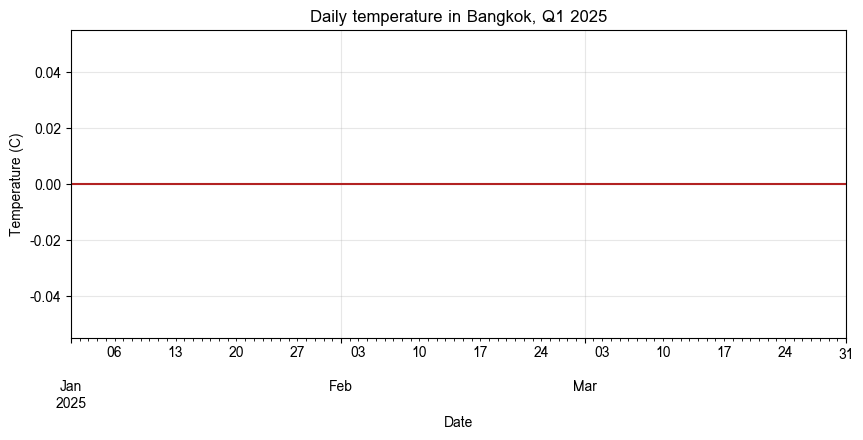

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

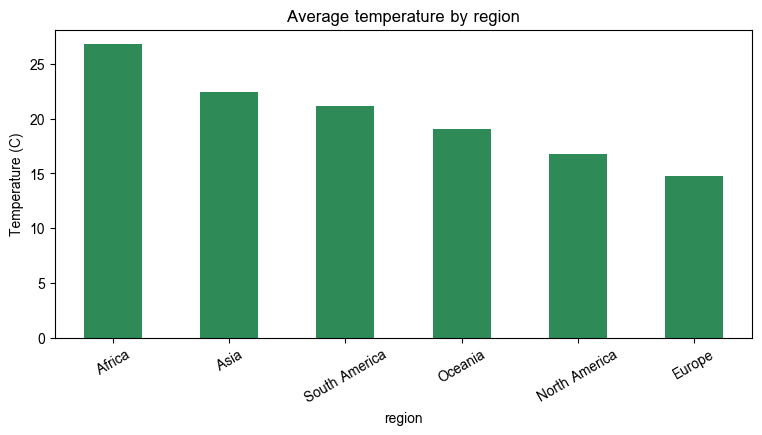

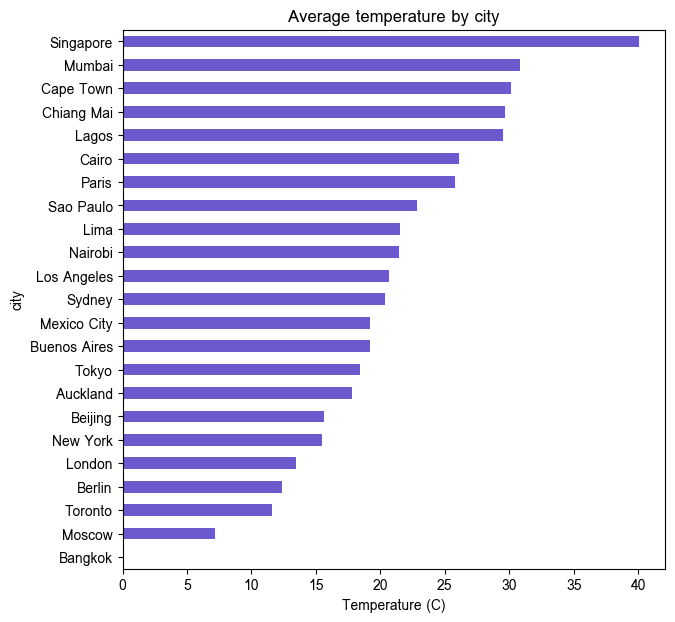

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

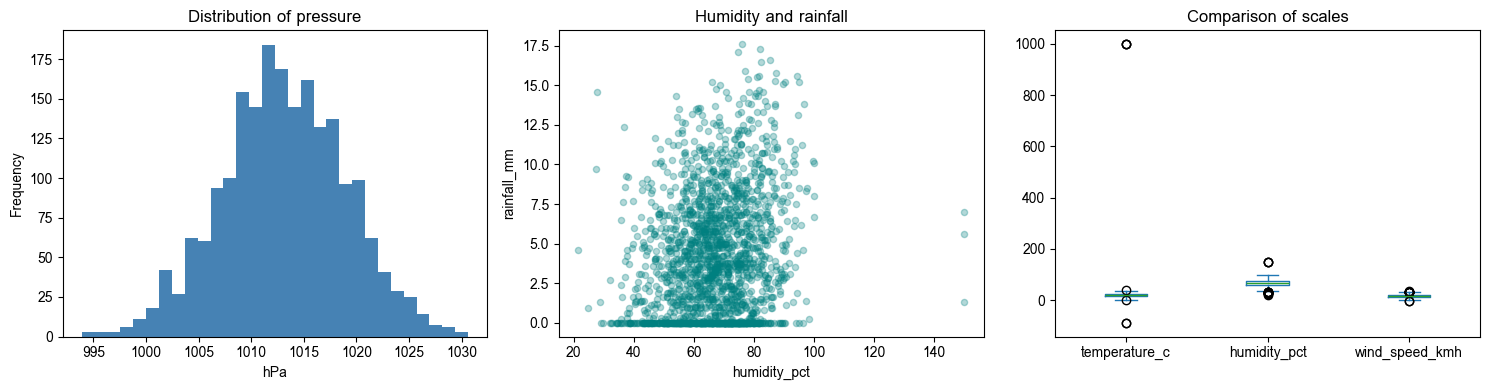

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

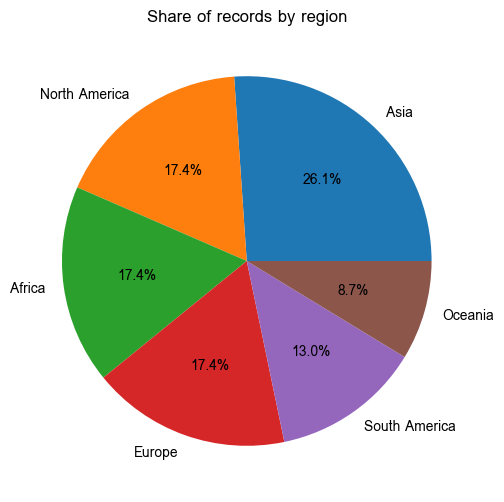

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

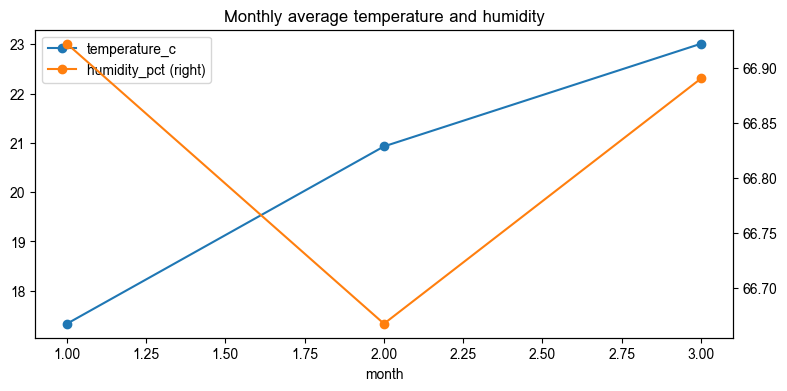

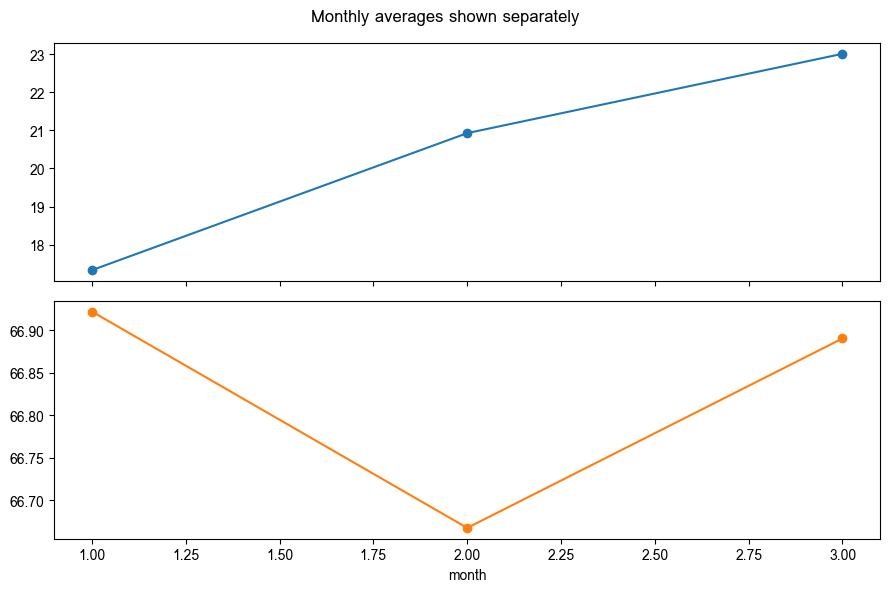

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

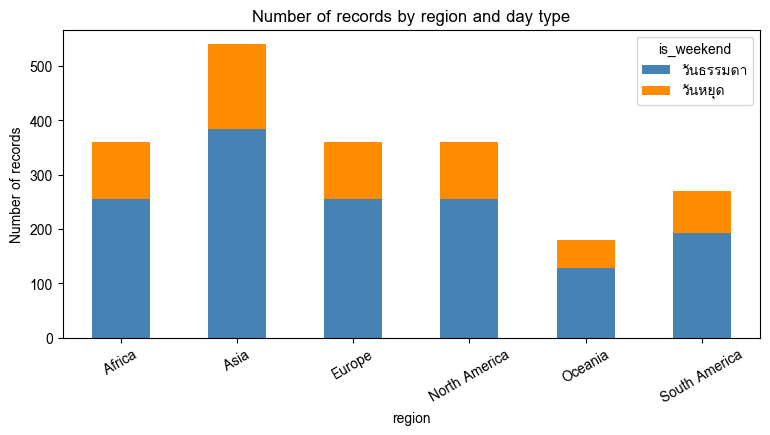

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

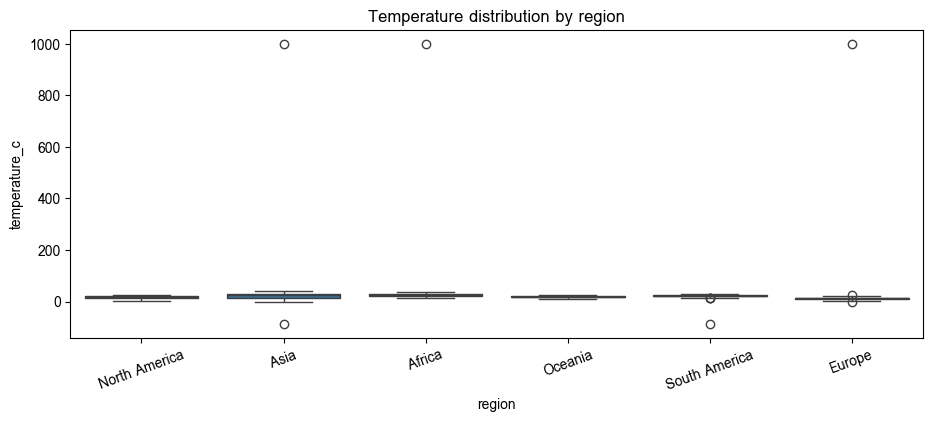

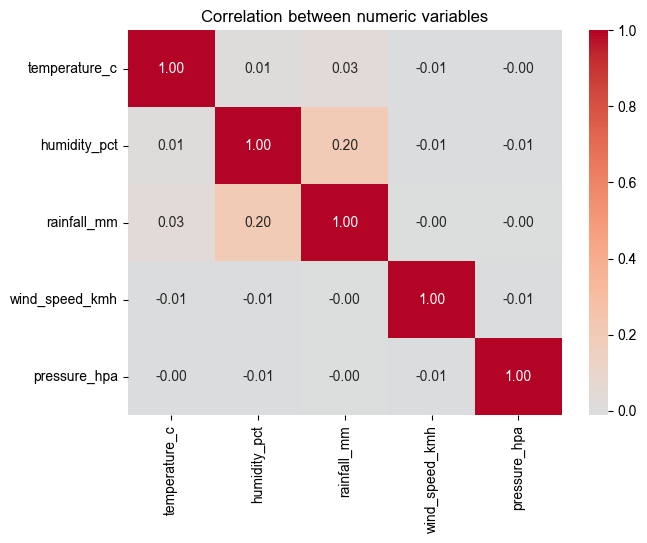

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

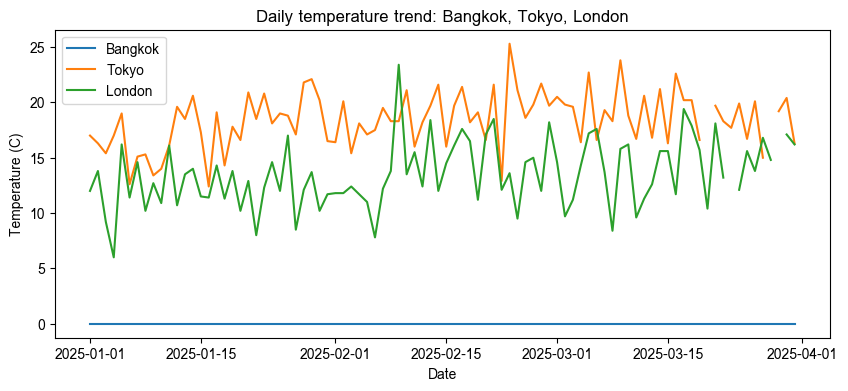

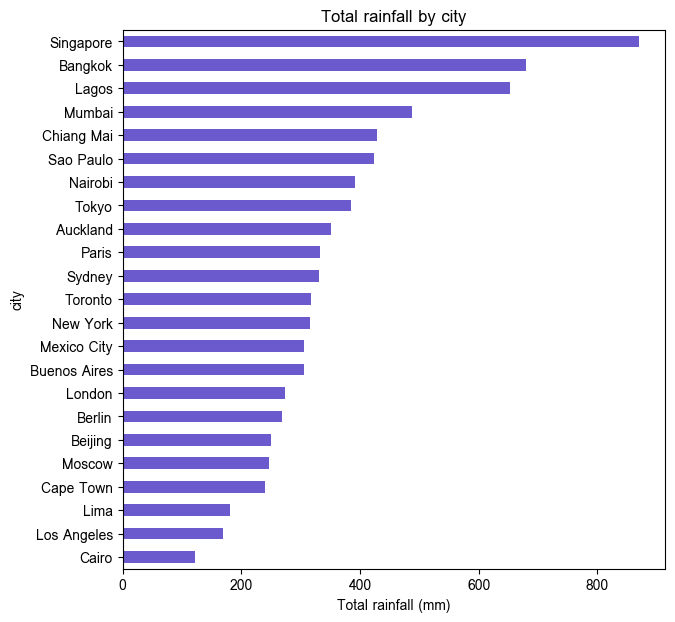

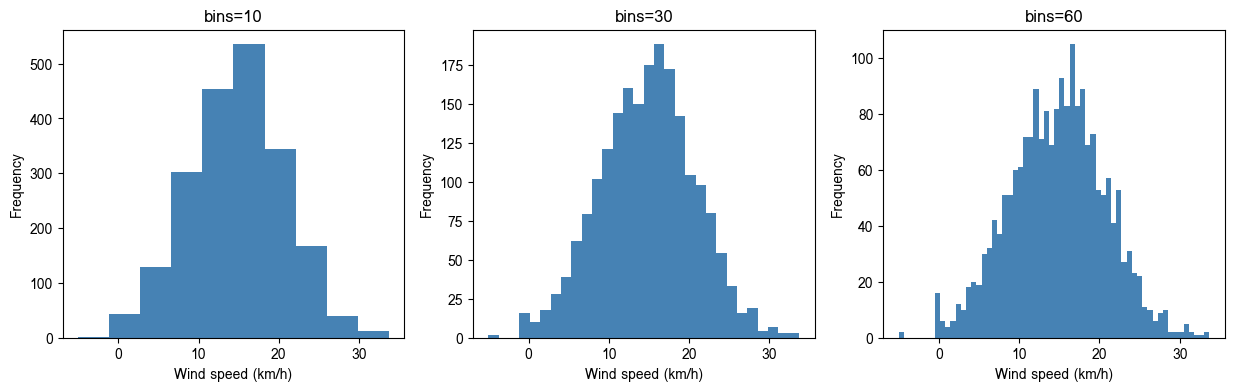

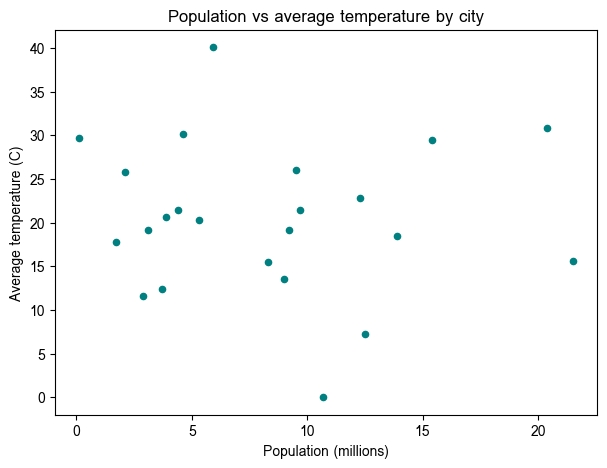

In [ ]:
# คำตอบข้อ 17.1
fig, ax = plt.subplots(figsize=(10, 4))
for c in ["Bangkok", "Tokyo", "London"]:
    tmp = df[df["city"] == c].sort_values("date")
    ax.plot(tmp["date"], tmp["temperature_c"], label=c)
ax.set_title("Daily temperature trend: Bangkok, Tokyo, London")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.legend()
plt.show()

rain_by_city_171 = df.groupby("city")["rainfall_mm"].sum().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
rain_by_city_171.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Total rainfall by city")
ax.set_xlabel("Total rainfall (mm)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, b in zip(axes, [10, 30, 60]):
    df["wind_speed_kmh"].plot(kind="hist", bins=b, ax=ax, color="steelblue")
    ax.set_title(f"bins={b}")
    ax.set_xlabel("Wind speed (km/h)")
plt.show()

city_temp_pop = df.groupby("city")["temperature_c"].mean().reset_index(name="avg_temp")
city_temp_pop = city_temp_pop.merge(city_info[["city", "population_millions"]], on="city", how="left")

fig, ax = plt.subplots(figsize=(7, 5))
city_temp_pop.plot(kind="scatter", x="population_millions", y="avg_temp", ax=ax, color="teal")
ax.set_title("Population vs average temperature by city")
ax.set_xlabel("Population (millions)")
ax.set_ylabel("Average temperature (C)")
plt.show()


อธิบาย bins: จำนวน bins น้อยทำให้เห็นภาพรวมการกระจายแบบหยาบ อาจซ่อนรายละเอียดของการกระจายตัว ส่วนจำนวน bins
มากทำให้เห็นรายละเอียดมากขึ้น แต่หากมากเกินไปจะทำให้กราฟดูรกและมีสัญญาณรบกวน (noise) มากขึ้น การเลือกจำนวน
bins ที่เหมาะสมต้องสมดุลระหว่างความละเอียดกับความเรียบง่ายในการตีความ

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

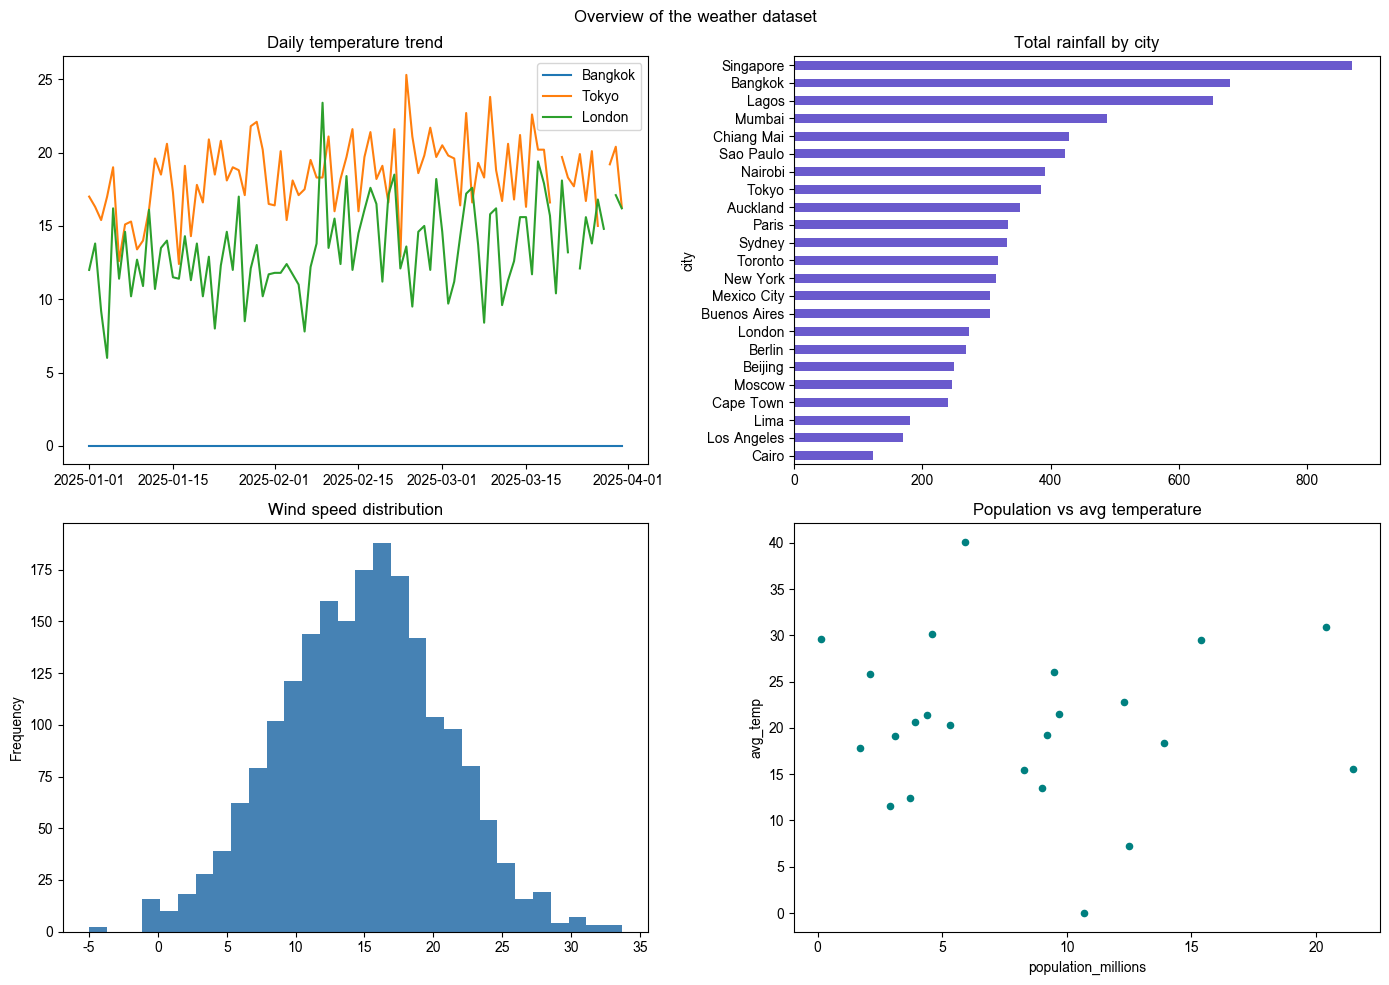

In [ ]:
# คำตอบข้อ 17.2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for c in ["Bangkok", "Tokyo", "London"]:
    tmp = df[df["city"] == c].sort_values("date")
    axes[0, 0].plot(tmp["date"], tmp["temperature_c"], label=c)
axes[0, 0].set_title("Daily temperature trend")
axes[0, 0].legend()

rain_by_city_171.plot(kind="barh", ax=axes[0, 1], color="slateblue")
axes[0, 1].set_title("Total rainfall by city")

df["wind_speed_kmh"].plot(kind="hist", bins=30, ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Wind speed distribution")

city_temp_pop.plot(kind="scatter", x="population_millions", y="avg_temp", ax=axes[1, 1], color="teal")
axes[1, 1].set_title("Population vs avg temperature")

plt.suptitle("Overview of the weather dataset")
plt.tight_layout()
plt.show()

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

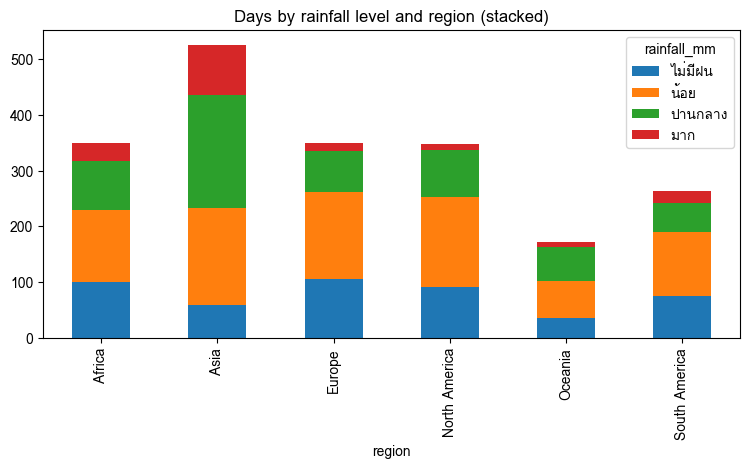

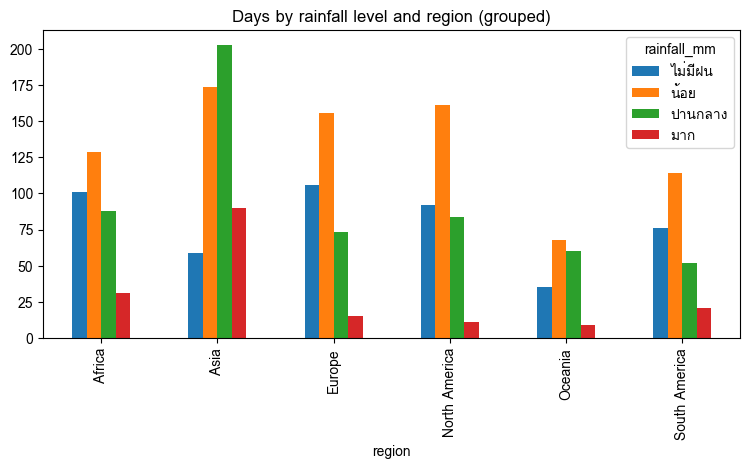

In [ ]:
# คำตอบข้อ 17.3
rain_bin_173 = pd.cut(df["rainfall_mm"], bins=[-0.1, 0, 5, 10, 100],
                      labels=["ไม่มีฝน", "น้อย", "ปานกลาง", "มาก"])
rain_region_173 = df.groupby(["region", rain_bin_173], observed=True).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
rain_region_173.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Days by rainfall level and region (stacked)")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
rain_region_173.plot(kind="bar", stacked=False, ax=ax)
ax.set_title("Days by rainfall level and region (grouped)")
plt.show()


อธิบาย: กราฟแท่งซ้อนเหมาะกับการดูภาพรวมยอดรวมของแต่ละภูมิภาคพร้อมสัดส่วนของแต่ละช่วงฝนในแท่งเดียว ส่วนกราฟ
แท่งเรียงข้างกันเหมาะกับการเปรียบเทียบจำนวนวันของแต่ละช่วงฝนระหว่างภูมิภาคโดยตรง เพราะดูความสูงของแท่ง
แต่ละแท่งเทียบกันได้ง่ายกว่าเมื่อไม่ได้ซ้อนกัน

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

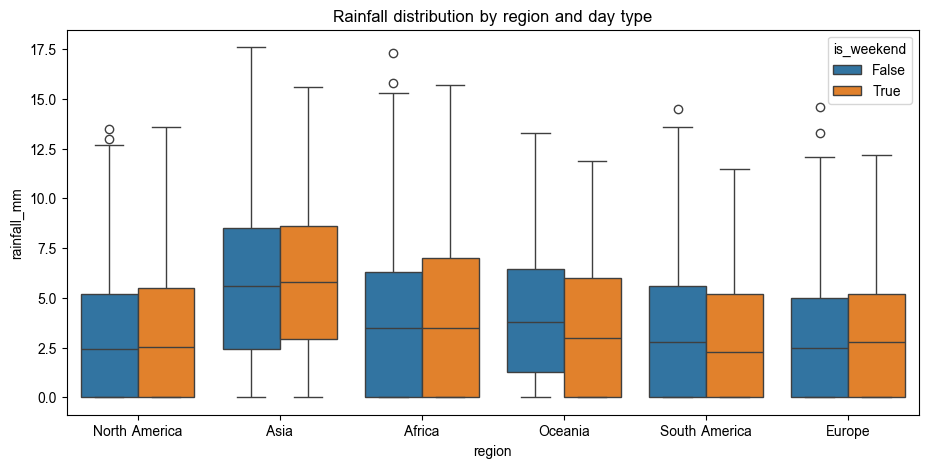

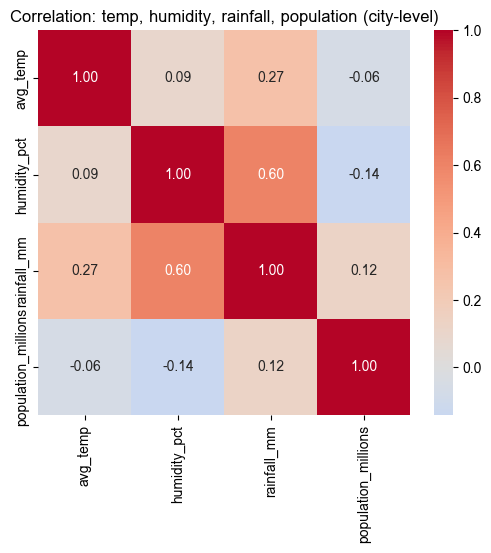

In [ ]:
# คำตอบข้อ 17.4
df["is_weekend"] = df["date"].dt.dayofweek >= 5
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="region", y="rainfall_mm", hue="is_weekend", ax=ax)
ax.set_title("Rainfall distribution by region and day type")
plt.show()

corr_cols_174 = city_temp_pop.merge(
    df.groupby("city")[["humidity_pct", "rainfall_mm"]].mean().reset_index(), on="city"
)[["avg_temp", "humidity_pct", "rainfall_mm", "population_millions"]]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_cols_174.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation: temp, humidity, rainfall, population (city-level)")
plt.show()


ตีความ: จากกราฟ boxplot สามารถดูได้ว่าปริมาณฝนวันหยุดสุดสัปดาห์กับวันธรรมดาในแต่ละภูมิภาคแตกต่างกันมากน้อยเพียงใด
ส่วน heatmap แสดงว่าตัวแปรใดมีความสัมพันธ์กันชัดเจน (ค่าเข้าใกล้ 1 หรือ -1) และตัวแปรใดแทบไม่สัมพันธ์กัน (ใกล้ 0)
ซึ่งช่วยชี้แนวทางว่าปัจจัยใดควรนำไปพิจารณาร่วมกันในการวิเคราะห์ขั้นถัดไป

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [ ]:
# คำตอบข้อ 18.1
city_info_181 = city_info.drop(columns=["region"], errors="ignore")

df18 = (
    df.merge(city_info_181, on="city", how="left")
      .merge(region_info, on="region", how="left")
)
df18["temperature_c"] = df18["temperature_c"].where(df18["temperature_c"].between(-60, 60))
df18["humidity_pct"] = df18["humidity_pct"].where(df18["humidity_pct"].between(0, 100))

q1_df = df18[df18["month"].isin([1, 2, 3])]

std_by_region_181 = q1_df.groupby("region")["temperature_c"].std().sort_values(ascending=False)
print("ส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายภูมิภาค (ไตรมาสแรก):")
print(std_by_region_181.round(2))

most_variable_region = std_by_region_181.index[0]
std_by_city_181 = (
    q1_df[q1_df["region"] == most_variable_region]
    .groupby("city")["temperature_c"].std().sort_values(ascending=False)
)
print(f"\nภูมิภาคที่แปรปรวนมากที่สุด: {most_variable_region}")
print("ส่วนเบี่ยงเบนมาตรฐานรายเมืองในภูมิภาคนี้:")
print(std_by_city_181.round(2))

ส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายภูมิภาค (ไตรมาสแรก):
region
Asia             11.43
Africa            4.88
North America     4.52
Europe            4.07
Oceania           3.08
South America     3.06
Name: temperature_c, dtype: float64

ภูมิภาคที่แปรปรวนมากที่สุด: Asia
ส่วนเบี่ยงเบนมาตรฐานรายเมืองในภูมิภาคนี้:
city
Beijing       2.87
Chiang Mai    2.86
Singapore     2.71
Mumbai        2.54
Tokyo         2.52
Bangkok       0.00
Name: temperature_c, dtype: float64

สรุป: ภูมิภาค Asia มีอุณหภูมิแปรปรวนมากที่สุดในไตรมาสแรกเมื่อวัดจากส่วนเบี่ยงเบนมาตรฐาน
หากค่า std รายเมืองข้างต้นใกล้เคียงกันทุกเมือง แสดงว่าความแปรปรวนเกิดจากทุกเมืองในภูมิภาคใกล้เคียงกัน แต่หากมี
เมืองใดเมืองหนึ่งมีค่า std สูงกว่าเมืองอื่นอย่างชัดเจน แสดงว่าความแปรปรวนของทั้งภูมิภาคเกิดจากเมืองนั้นเป็นหลัก
(วิธีจัดการค่าผิดปกติที่ใช้: แทนค่าอุณหภูมินอกช่วง -60 ถึง 60 องศาด้วยค่าว่างก่อนคำนวณ)



สรุป: ภูมิภาค Asia  มีอุณหภูมิแปรปรวนมากที่สุดในไตรมาสแรกเมื่อวัดจากส่วนเบี่ยงเบนมาตรฐาน
หากค่า std รายเมืองข้างต้นใกล้เคียงกันทุกเมือง แสดงว่าความแปรปรวนเกิดจากทุกเมืองในภูมิภาคใกล้เคียงกัน แต่หากมี
เมืองใดเมืองหนึ่งมีค่า std สูงกว่าเมืองอื่นอย่างชัดเจน แสดงว่าความแปรปรวนของทั้งภูมิภาคเกิดจากเมืองนั้นเป็นหลัก
(วิธีจัดการค่าผิดปกติที่ใช้: แทนค่าอุณหภูมินอกช่วง -60 ถึง 60 องศาด้วยค่าว่างก่อนคำนวณ)

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [ ]:
# คำตอบข้อ 18.2
heavy_days_182 = df18.groupby("city")["rainfall_mm"].apply(lambda s: (s > 10).sum())
total_days_182 = df18.groupby("city")["rainfall_mm"].count()
heavy_pct_182 = (heavy_days_182 / total_days_182 * 100)

print("5 อันดับแรกเมื่อวัดด้วยจำนวนวัน:")
print(heavy_days_182.nlargest(5))
print("\n5 อันดับแรกเมื่อวัดด้วยสัดส่วน:")
print(heavy_pct_182.nlargest(5).round(2))

5 อันดับแรกเมื่อวัดด้วยจำนวนวัน:
city
Singapore       44
Bangkok         23
Lagos           22
Sao Paulo       11
Buenos Aires     9
Name: rainfall_mm, dtype: int64

5 อันดับแรกเมื่อวัดด้วยสัดส่วน:
city
Singapore     48.89
Bangkok       26.44
Lagos         25.00
Sao Paulo     12.50
Chiang Mai    10.59
Name: rainfall_mm, dtype: float64

สรุป: ผลทั้งสองแบบให้อันดับต่างกันเพราะจำนวนวันข้อมูลของแต่ละเมืองไม่เท่ากัน เมืองที่มีข้อมูลมากมีโอกาสสะสม
จำนวนวันฝนตกหนักได้มากกว่าโดยธรรมชาติแม้ฝนจะไม่ได้ตกหนักบ่อยเป็นพิเศษ ในขณะที่สัดส่วนช่วยปรับฐานให้เทียบกันได้
เป็นธรรมมากกว่าเมื่อจำนวนวันข้อมูลของแต่ละเมืองไม่เท่ากัน



สรุป: ผลทั้งสองแบบให้อันดับต่างกันเพราะจำนวนวันข้อมูลของแต่ละเมืองไม่เท่ากัน เมืองที่มีข้อมูลมากมีโอกาสสะสม
จำนวนวันฝนตกหนักได้มากกว่าโดยธรรมชาติแม้ฝนจะไม่ได้ตกหนักบ่อยเป็นพิเศษ ในขณะที่สัดส่วนช่วยปรับฐานให้เทียบกันได้
เป็นธรรมมากกว่าเมื่อจำนวนวันข้อมูลของแต่ละเมืองไม่เท่ากัน

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

In [ ]:
# คำตอบข้อ 18.3
city_level_183 = df18.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    avg_rain=("rainfall_mm", "mean"),
    population=("population_millions", "first"),
).dropna()

corr_temp_pop = city_level_183["population"].corr(city_level_183["avg_temp"])
corr_rain_pop = city_level_183["population"].corr(city_level_183["avg_rain"])

print(f"สหสัมพันธ์ระหว่างประชากรกับอุณหภูมิเฉลี่ย: {corr_temp_pop:.3f}")
print(f"สหสัมพันธ์ระหว่างประชากรกับปริมาณฝนเฉลี่ย: {corr_rain_pop:.3f}")

สหสัมพันธ์ระหว่างประชากรกับอุณหภูมิเฉลี่ย: 0.062
สหสัมพันธ์ระหว่างประชากรกับปริมาณฝนเฉลี่ย: 0.123

ข้อควรระวังในการตีความ: จำนวนเมืองในชุดข้อมูลมีไม่มาก (23 เมือง) ค่าสหสัมพันธ์ที่คำนวณได้จึงอาจไม่เสถียร
และอ่อนไหวต่อค่าผิดปกติของเมืองใดเมืองหนึ่งได้ง่าย นอกจากนี้สหสัมพันธ์เป็นเพียงการวัดความสัมพันธ์เชิงเส้น
ไม่ได้บ่งชี้ความเป็นเหตุเป็นผล (correlation ไม่ใช่ causation) ประชากรเมืองอาจสัมพันธ์กับปัจจัยอื่น เช่น
ละติจูดหรือภูมิภาคที่ตั้ง มากกว่าที่จะส่งผลต่ออุณหภูมิหรือปริมาณฝนโดยตรง



ข้อควรระวังในการตีความ: จำนวนเมืองในชุดข้อมูลมีไม่มาก (23 เมือง) ค่าสหสัมพันธ์ที่คำนวณได้จึงอาจไม่เสถียร
และอ่อนไหวต่อค่าผิดปกติของเมืองใดเมืองหนึ่งได้ง่าย นอกจากนี้สหสัมพันธ์เป็นเพียงการวัดความสัมพันธ์เชิงเส้น
ไม่ได้บ่งชี้ความเป็นเหตุเป็นผล (correlation ไม่ใช่ causation) ประชากรเมืองอาจสัมพันธ์กับปัจจัยอื่น เช่น
ละติจูดหรือภูมิภาคที่ตั้ง มากกว่าที่จะส่งผลต่ออุณหภูมิหรือปริมาณฝนโดยตรง

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

In [ ]:
# คำตอบข้อ 18.4
df18["is_weekend"] = df18["date"].dt.dayofweek >= 5

travel_risk_184 = df18.groupby(["region", "month"]).agg(
    avg_rain=("rainfall_mm", "mean"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    avg_wind=("wind_speed_kmh", "mean"),
).reset_index()

# เกณฑ์: ใช้คะแนนความเสี่ยงจากอันดับเปอร์เซ็นไทล์ของฝนเฉลี่ยรวมกับลมเฉลี่ย เดือนที่คะแนนสูงสุดของแต่ละภูมิภาค
# คือเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
travel_risk_184["risk_score"] = (
    travel_risk_184["avg_rain"].rank(pct=True) + travel_risk_184["avg_wind"].rank(pct=True)
)
worst_month_by_region = travel_risk_184.loc[
    travel_risk_184.groupby("region")["risk_score"].idxmax()
][["region", "month", "avg_rain", "avg_wind", "risk_score"]]

print(worst_month_by_region.round(2))

           region  month  avg_rain  avg_wind  risk_score
0          Africa      1      4.22     15.59        1.72
5            Asia      3      5.66     15.89        1.89
7          Europe      2      3.24     15.01        1.00
10  North America      2      3.26     14.88        0.89
14        Oceania      3      4.38     14.55        1.28
15  South America      1      3.34     14.95        1.06

เกณฑ์ที่เลือกใช้: กำหนดคะแนนความเสี่ยง (risk_score) จากอันดับเปอร์เซ็นไทล์ของปริมาณฝนเฉลี่ยรวมกับอันดับ
เปอร์เซ็นไทล์ของความเร็วลมเฉลี่ยในแต่ละคู่ภูมิภาค-เดือน เพราะทั้งฝนตกหนักและลมแรงเป็นปัจจัยหลักที่ส่งผลกระทบ
ต่อการเดินทาง (ความล่าช้าของเที่ยวบิน ถนนลื่น ทัศนวิสัยต่ำ) เดือนที่มีคะแนนรวมสูงสุดของแต่ละภูมิภาคจึงถูกเลือก
เป็นเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุด



เกณฑ์ที่เลือกใช้: กำหนดคะแนนความเสี่ยง (risk_score) จากอันดับเปอร์เซ็นไทล์ของปริมาณฝนเฉลี่ยรวมกับอันดับ
เปอร์เซ็นไทล์ของความเร็วลมเฉลี่ยในแต่ละคู่ภูมิภาค-เดือน เพราะทั้งฝนตกหนักและลมแรงเป็นปัจจัยหลักที่ส่งผลกระทบ
ต่อการเดินทาง (ความล่าช้าของเที่ยวบิน ถนนลื่น ทัศนวิสัยต่ำ) เดือนที่มีคะแนนรวมสูงสุดของแต่ละภูมิภาคจึงถูกเลือก
เป็นเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุด

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️